# Analyzing the planets in OGLE-2006-BLG-109L

In [1]:
# Importing crap
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('../..')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.patches as patches

import IRSMicroLensing.IRSFunctions as IRSF
import IRSMicroLensing.IRSCaustics as IRSC

import VBMicrolensing
import MulensModel as mm
import numexpr

import astropy
import astropy.units as u
import astropy.constants as c

import csv

plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['figure.titlesize'] = 20
plt.rcParams['figure.titleweight'] = 'bold'
plt.rcParams['figure.figsize'] = (10, 8)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['figure.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['mathtext.fontset'] = 'cm'

In [4]:
# Distance to source plane
D_s = 8 * u.kpc

# Distance to lens plane
D_l = 1.5 * u.kpc

# Mass of star
M_star = 0.5 * c.M_sun

theta_ein, r_ein = IRSF.IRSFunctions.e_ring([D_s, D_l], M_star.to(u.M_sun).value)
print(f'Einstein ring radius: {r_ein}')
print(f'Einstein ring angle: {theta_ein}')

planets = ['False Mercury', 'False Venus', 'False Earth', 'False Mars', 'b', 'c', 'False Uranus', 'False Neptune']

# Defining our Jupiter for scale
r_jupiter = 5.2

# Defining semimajor axes of known planets
r_b = 2.3
r_c = 4.6

# Defining semimajor axes of false Solar System-like planets
r_false_uranus = 19.2 * (r_b / r_jupiter)
r_false_neptune = 30.07 * (r_b / r_jupiter)
r_false_mercury = 0.387 * (r_b / r_jupiter)
r_false_venus = 0.723 * (r_b / r_jupiter)
r_false_earth = 1 * (r_b / r_jupiter)
r_false_mars = 1.524 * (r_b / r_jupiter)

planet_semimajor_axes = np.array([r_false_mercury, r_false_venus, r_false_earth, r_false_mars, r_b, r_c, r_false_uranus, r_false_neptune]) * u.au # au

# Calculating in terms of theta_E
planet_ss = (planet_semimajor_axes / r_ein).to(u.dimensionless_unscaled).value # theta_E

# Defining our Jupiter mass for scale
m_jupiter = 1898.125e24

# Defining masses of known planets
m_b = 0.71 * c.M_jup.to(u.kg).value
m_c = 0.27 * c.M_jup.to(u.kg).value

# Defining masses of false Solar System-like planets
m_false_uranus = 86.8099e24 * (m_b / m_jupiter)
m_false_neptune = 102.4092e24 * (m_b / m_jupiter)
m_false_mercury = 0.330103e24 * (m_b / m_jupiter)
m_false_venus = 4.86731e24 * (m_b / m_jupiter)
m_false_earth = 5.97217e24 * (m_b / m_jupiter)
m_false_mars = 0.641691e24 * (m_b / m_jupiter)

planet_masses = np.array([m_false_mercury, m_false_venus, m_false_earth, m_false_mars, m_b, m_c, m_false_uranus, m_false_neptune]) * u.kg # kg

# Calculating in terms of M_sun
planet_qs = (planet_masses / M_star).to(u.dimensionless_unscaled).value # dimensionless

# Defining shears
planet_shears = []
for i in range(len(planets)):
    q = planet_qs[i]
    s = planet_ss[i]
    if s < 1:
        planet_shears.append(q * s**2)
    else:
        planet_shears.append(q * (1/s)**2)

planet_shears = np.array(planet_shears)

# Defining planet angles
seed = 3
np.random.seed(seed)
planet_alphas = np.random.uniform(0, 360, len(planets))

# Adding all attributes to a Pandas DataFrame
planet_attributes = pd.DataFrame({
    'Planet': planets,
    'Semimajor Axis [au]': planet_semimajor_axes,
    's': planet_ss,
    'Mass [kg]': planet_masses,
    'q': planet_qs,
    'Shear': planet_shears,
    'Angle [deg]': planet_alphas
})

planet_attributes

Einstein ring radius: 2.2277029852535475 AU
Einstein ring angle: 1.485135323502365 mas


,Planet,Semimajor Axis [au],s,Mass [kg],q,Shear,Angle [deg]
0,False Mercury,0.171173,0.076838,2.343731e+23,2.357392e-07,1.391836e-09,198.287245
1,False Venus,0.319788,0.143551,3.455789e+24,3.475933e-06,7.162792e-08,254.933216
2,False Earth,0.442308,0.198549,4.240240e+24,4.264955e-06,1.681314e-07,104.725706
3,False Mars,0.674077,0.302588,4.556005e+23,4.582561e-07,4.195779e-08,183.897938
4,b,2.300000,1.032454,1.347668e+27,1.355524e-03,1.271645e-03,321.460904
5,c,4.600000,2.064907,5.124936e+26,5.154809e-04,1.208959e-04,322.665512
6,False Uranus,8.492308,3.812136,6.163502e+25,6.199428e-05,4.265940e-06,45.210712
7,False Neptune,13.300192,5.970362,7.271052e+25,7.313433e-05,2.051729e-06,74.607436


In [5]:
# Sorting planets by shear
planet_attributes = planet_attributes.sort_values(by='Shear', ascending=False)

planet_attributes

,Planet,Semimajor Axis [au],s,Mass [kg],q,Shear,Angle [deg]
4,b,2.300000,1.032454,1.347668e+27,1.355524e-03,1.271645e-03,321.460904
5,c,4.600000,2.064907,5.124936e+26,5.154809e-04,1.208959e-04,322.665512
6,False Uranus,8.492308,3.812136,6.163502e+25,6.199428e-05,4.265940e-06,45.210712
7,False Neptune,13.300192,5.970362,7.271052e+25,7.313433e-05,2.051729e-06,74.607436
2,False Earth,0.442308,0.198549,4.240240e+24,4.264955e-06,1.681314e-07,104.725706
1,False Venus,0.319788,0.143551,3.455789e+24,3.475933e-06,7.162792e-08,254.933216
3,False Mars,0.674077,0.302588,4.556005e+23,4.582561e-07,4.195779e-08,183.897938
0,False Mercury,0.171173,0.076838,2.343731e+23,2.357392e-07,1.391836e-09,198.287245


Defining lens attributes

In [6]:
lens_att = []
lens_att.append([0, 0, 1])

for i in range(len(planets)):
    lens_att.append([planet_attributes['s'].iloc[i] * np.cos(np.deg2rad(planet_attributes['Angle [deg]'].iloc[i])), planet_attributes['s'].iloc[i] * np.sin(np.deg2rad(planet_attributes['Angle [deg]'].iloc[i])), planet_attributes['q'].iloc[i]])

lens_att = np.array(lens_att)

lens_att

array([[ 0.00000000e+00,  0.00000000e+00,  1.00000000e+00],
       [ 8.07567867e-01, -6.43268690e-01,  1.35552381e-03],
       [ 1.64182544e+00, -1.25229832e+00,  5.15480886e-04],
       [ 2.68565598e+00,  2.70548260e+00,  6.19942768e-05],
       [ 1.58471899e+00,  5.75620388e+00,  7.31343348e-05],
       [-5.04694872e-02,  1.92027201e-01,  4.26495549e-06],
       [-3.73152671e-02, -1.38615988e-01,  3.47593262e-06],
       [-3.01888359e-01, -2.05697679e-02,  4.58256137e-07],
       [-7.29576799e-02, -2.41104289e-02,  2.35739204e-07]])

Showing planet configuration

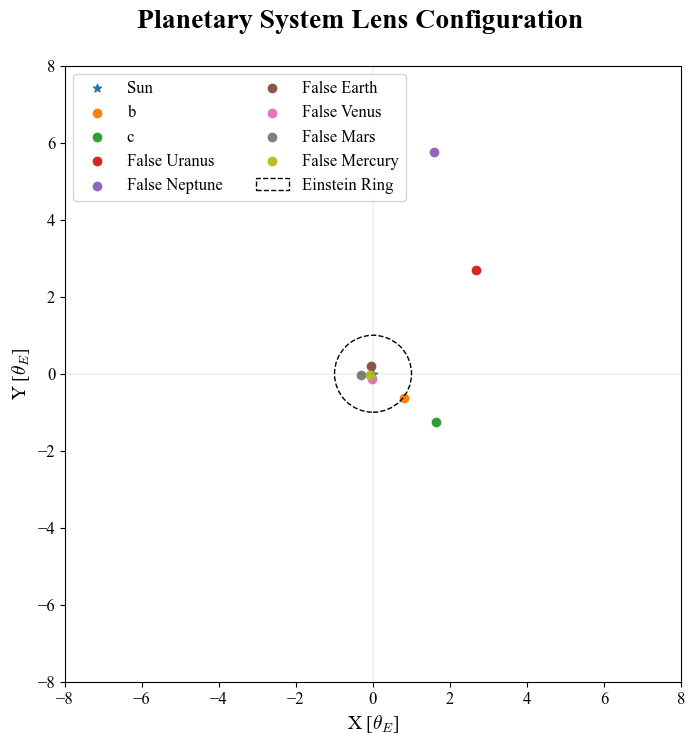

In [7]:
fig = plt.figure()
ax = fig.add_subplot()

fig.suptitle('Planetary System Lens Configuration', y=0.95)

for i in range(lens_att.shape[0]):
    ax.scatter(lens_att[i, 0], lens_att[i, 1], label=planet_attributes['Planet'].iloc[i-1] if i != 0 else 'Sun', marker='*' if i == 0 else 'o')

ring_patch = patches.Circle((0, 0), radius=1, fill=None, edgecolor='black', linestyle='--', label='Einstein Ring')
ax.add_patch(ring_patch)

ax.set_aspect('equal')

ax.set_xlabel(r'X [$\theta_E$]')
ax.set_ylabel(r'Y [$\theta_E$]')

view = 8
ax.set_xlim(-view, view)
ax.set_ylim(-view, view)
ax.hlines(0, -view, view, colors='black', linestyles='dashed', linewidth=0.1)
ax.vlines(0, -view, view, colors='black', linestyles='dashed', linewidth=0.1)

ax.legend(ncol=2, loc='best')

# fig.savefig('Lens Configuration.png', dpi=300)

plt.show()

Creating magnification maps

Binary offset: [0.0006765 0.       ]
[[-6.76499369e-04  0.00000000e+00  1.00000000e+00]
 [ 8.06891367e-01 -6.43268690e-01  1.35552381e-03]]
4    b
Name: Planet, dtype: object
Pixels = 4514, Angular Width = 1.5, Max Source Radius = 6.642182487729043, Min Source Radius = 0.06642182487729043
q = 0.0013555238122364413, s = 1.0324536148782077
Annulus bounds: y+ = 1.7014326379427267, y- = 0.587148243918636, Min Magnification in Annulus = 1.2690920405970603
Number of rays: num_r = 1511868, num_theta = 377967, Total number of rays: 5.714e+11


100%|██████████| 500/500 [00:02<00:00, 230.01it/s]


---------------------
Total time: 2.214 seconds
Plotting magnification map: 0.021 seconds


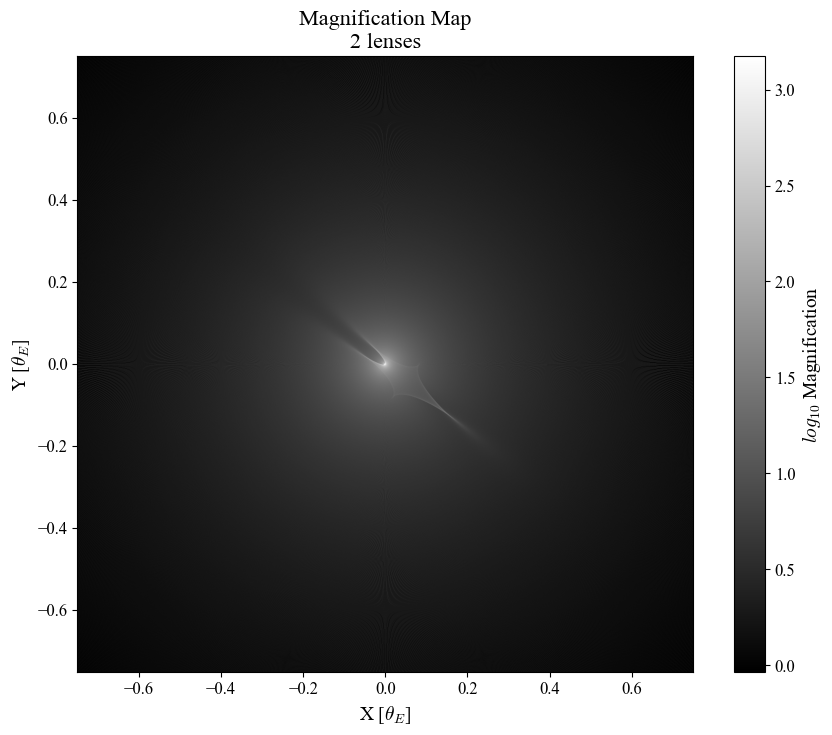

[[-6.76499369e-04  0.00000000e+00  1.00000000e+00]
 [ 8.06891367e-01 -6.43268690e-01  1.35552381e-03]
 [ 1.64114895e+00 -1.25229832e+00  5.15480886e-04]]
4    b
5    c
Name: Planet, dtype: object
Pixels = 4514, Angular Width = 1.5, Max Source Radius = 6.642182487729043, Min Source Radius = 0.06642182487729043
q = 0.0013555238122364413, s = 1.0324536148782077
q = 0.0005154808863434355, s = 2.0649072297564155
Annulus bounds: y+ = 1.7014326379427267, y- = 0.587148243918636, Min Magnification in Annulus = 1.2690920405970603
Number of rays: num_r = 1511868, num_theta = 377967, Total number of rays: 5.714e+11


100%|██████████| 500/500 [00:02<00:00, 213.93it/s]


---------------------
Total time: 2.341 seconds
Plotting magnification map: 0.016 seconds


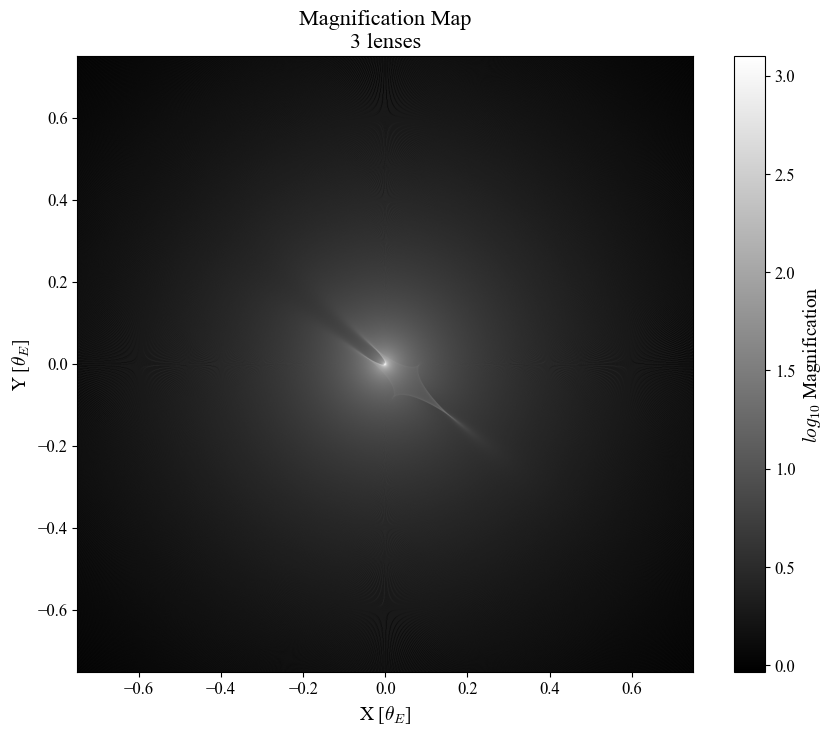

[[-6.76499369e-04  0.00000000e+00  1.00000000e+00]
 [ 8.06891367e-01 -6.43268690e-01  1.35552381e-03]
 [ 1.64114895e+00 -1.25229832e+00  5.15480886e-04]
 [ 2.68497948e+00  2.70548260e+00  6.19942768e-05]]
4               b
5               c
6    False Uranus
Name: Planet, dtype: object
Pixels = 4514, Angular Width = 1.5, Max Source Radius = 6.642182487729043, Min Source Radius = 0.06642182487729043
q = 0.0013555238122364413, s = 1.0324536148782077
q = 0.0005154808863434355, s = 2.0649072297564155
q = 6.199427676673783e-05, s = 3.8121364241656894
Annulus bounds: y+ = 1.7014326379427267, y- = 0.587148243918636, Min Magnification in Annulus = 1.2690920405970603
Number of rays: num_r = 1511868, num_theta = 377967, Total number of rays: 5.714e+11


100%|██████████| 500/500 [00:02<00:00, 195.71it/s]


---------------------
Total time: 2.559 seconds
Plotting magnification map: 0.017 seconds


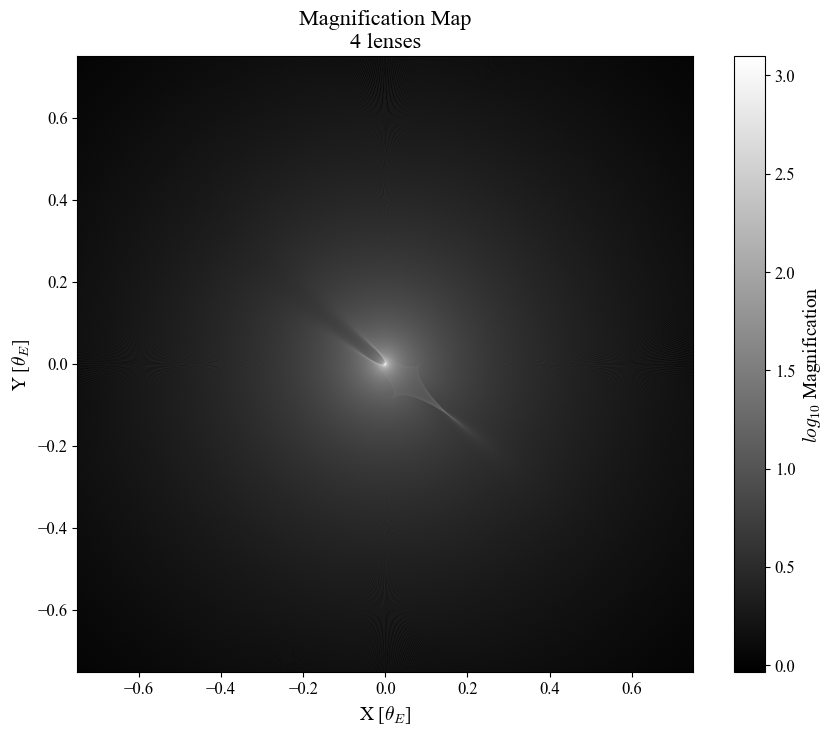

[[-6.76499369e-04  0.00000000e+00  1.00000000e+00]
 [ 8.06891367e-01 -6.43268690e-01  1.35552381e-03]
 [ 1.64114895e+00 -1.25229832e+00  5.15480886e-04]
 [ 2.68497948e+00  2.70548260e+00  6.19942768e-05]
 [ 1.58404249e+00  5.75620388e+00  7.31343348e-05]]
4                b
5                c
6     False Uranus
7    False Neptune
Name: Planet, dtype: object
Pixels = 4514, Angular Width = 1.5, Max Source Radius = 6.642182487729043, Min Source Radius = 0.06642182487729043
q = 0.0013555238122364413, s = 1.0324536148782077
q = 0.0005154808863434355, s = 2.0649072297564155
q = 6.199427676673783e-05, s = 3.8121364241656894
q = 7.313433477357085e-05, s = 5.970361576805329
Annulus bounds: y+ = 1.7014326379427267, y- = 0.587148243918636, Min Magnification in Annulus = 1.2690920405970603
Number of rays: num_r = 1511868, num_theta = 377967, Total number of rays: 5.714e+11


100%|██████████| 500/500 [00:02<00:00, 191.26it/s]


---------------------
Total time: 2.619 seconds
Plotting magnification map: 0.017 seconds


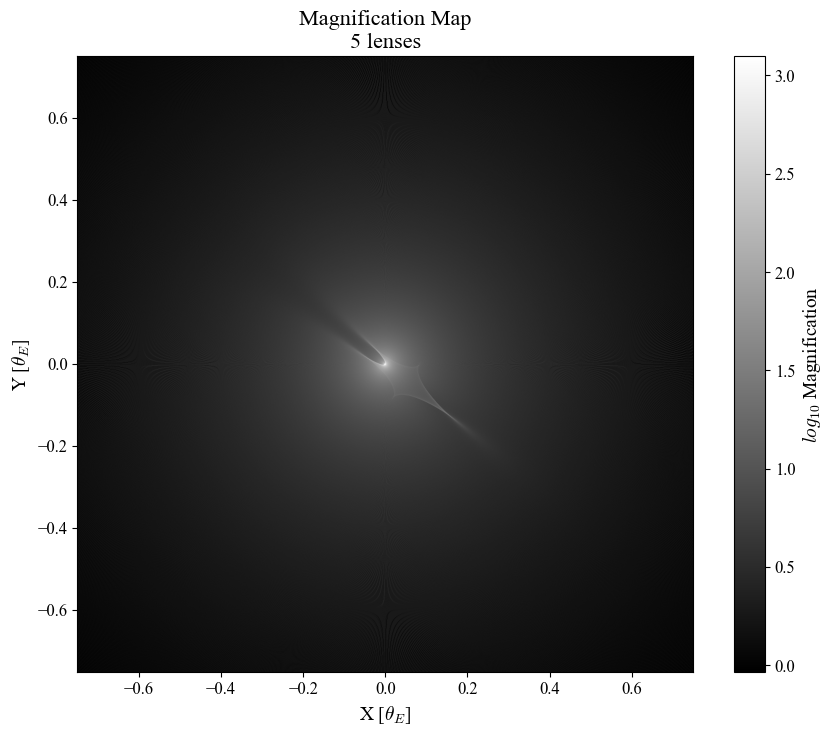

[[-6.76499369e-04  0.00000000e+00  1.00000000e+00]
 [ 8.06891367e-01 -6.43268690e-01  1.35552381e-03]
 [ 1.64114895e+00 -1.25229832e+00  5.15480886e-04]
 [ 2.68497948e+00  2.70548260e+00  6.19942768e-05]
 [ 1.58404249e+00  5.75620388e+00  7.31343348e-05]
 [-5.11459866e-02  1.92027201e-01  4.26495549e-06]]
4                b
5                c
6     False Uranus
7    False Neptune
2      False Earth
Name: Planet, dtype: object
Pixels = 4514, Angular Width = 1.5, Max Source Radius = 6.642182487729043, Min Source Radius = 0.06642182487729043
q = 0.0013555238122364413, s = 1.0324536148782077
q = 0.0005154808863434355, s = 2.0649072297564155
q = 6.199427676673783e-05, s = 3.8121364241656894
q = 7.313433477357085e-05, s = 5.970361576805329
q = 4.264955493302131e-06, s = 0.198548772091963
Annulus bounds: y+ = 1.7014330329661838, y- = 0.587148243918636, Min Magnification in Annulus = 1.2690920405970603
Number of rays: num_r = 1511868, num_theta = 377967, Total number of rays: 5.714e+11


100%|██████████| 500/500 [00:02<00:00, 187.31it/s]


---------------------
Total time: 2.673 seconds
Plotting magnification map: 0.017 seconds


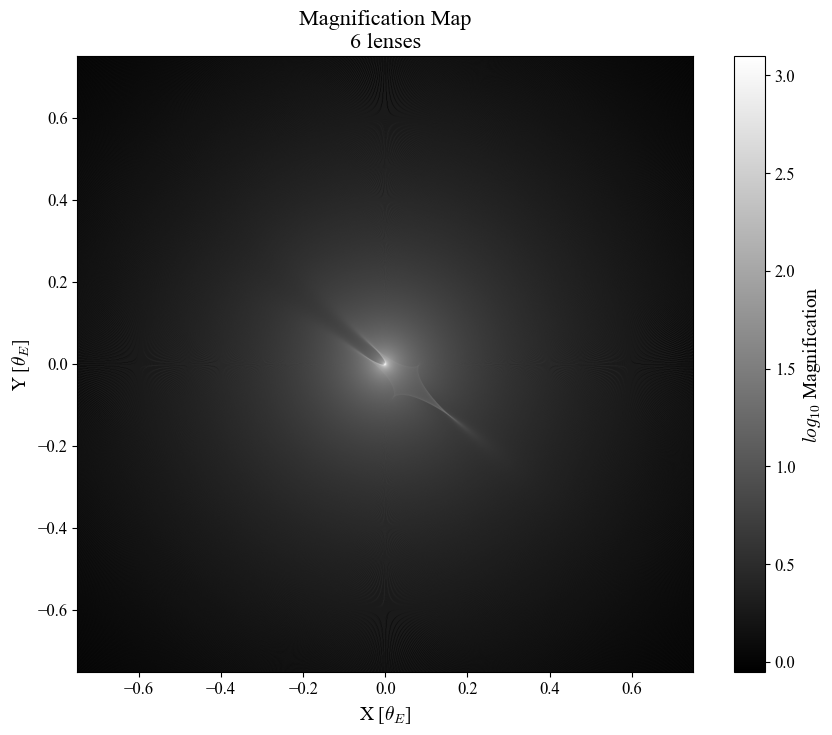

[[-6.76499369e-04  0.00000000e+00  1.00000000e+00]
 [ 8.06891367e-01 -6.43268690e-01  1.35552381e-03]
 [ 1.64114895e+00 -1.25229832e+00  5.15480886e-04]
 [ 2.68497948e+00  2.70548260e+00  6.19942768e-05]
 [ 1.58404249e+00  5.75620388e+00  7.31343348e-05]
 [-5.11459866e-02  1.92027201e-01  4.26495549e-06]
 [-3.79917664e-02 -1.38615988e-01  3.47593262e-06]]
4                b
5                c
6     False Uranus
7    False Neptune
2      False Earth
1      False Venus
Name: Planet, dtype: object
Pixels = 4514, Angular Width = 1.5, Max Source Radius = 6.642182487729043, Min Source Radius = 0.06642182487729043
q = 0.0013555238122364413, s = 1.0324536148782077
q = 0.0005154808863434355, s = 2.0649072297564155
q = 6.199427676673783e-05, s = 3.8121364241656894
q = 7.313433477357085e-05, s = 5.970361576805329
q = 4.264955493302131e-06, s = 0.198548772091963
q = 3.4759326211585397e-06, s = 0.14355076222248925
Annulus bounds: y+ = 1.7014330329662288, y- = 0.587148243918636, Min Magnification in

100%|██████████| 500/500 [00:02<00:00, 179.08it/s]


---------------------
Total time: 2.796 seconds
Plotting magnification map: 0.017 seconds


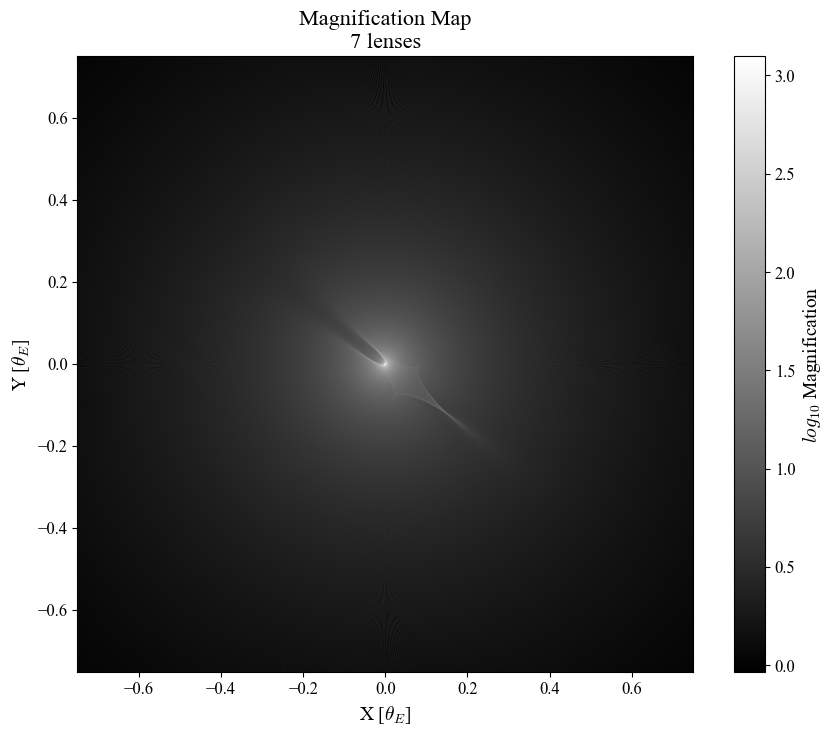

[[-6.76499369e-04  0.00000000e+00  1.00000000e+00]
 [ 8.06891367e-01 -6.43268690e-01  1.35552381e-03]
 [ 1.64114895e+00 -1.25229832e+00  5.15480886e-04]
 [ 2.68497948e+00  2.70548260e+00  6.19942768e-05]
 [ 1.58404249e+00  5.75620388e+00  7.31343348e-05]
 [-5.11459866e-02  1.92027201e-01  4.26495549e-06]
 [-3.79917664e-02 -1.38615988e-01  3.47593262e-06]
 [-3.02564858e-01 -2.05697679e-02  4.58256137e-07]]
4                b
5                c
6     False Uranus
7    False Neptune
2      False Earth
1      False Venus
3       False Mars
Name: Planet, dtype: object
Pixels = 4514, Angular Width = 1.5, Max Source Radius = 6.642182487729043, Min Source Radius = 0.06642182487729043
q = 0.0013555238122364413, s = 1.0324536148782077
q = 0.0005154808863434355, s = 2.0649072297564155
q = 6.199427676673783e-05, s = 3.8121364241656894
q = 7.313433477357085e-05, s = 5.970361576805329
q = 4.264955493302131e-06, s = 0.198548772091963
q = 3.4759326211585397e-06, s = 0.14355076222248925
q = 4.582561372

100%|██████████| 500/500 [00:03<00:00, 159.25it/s]


---------------------
Total time: 3.144 seconds
Plotting magnification map: 0.016 seconds


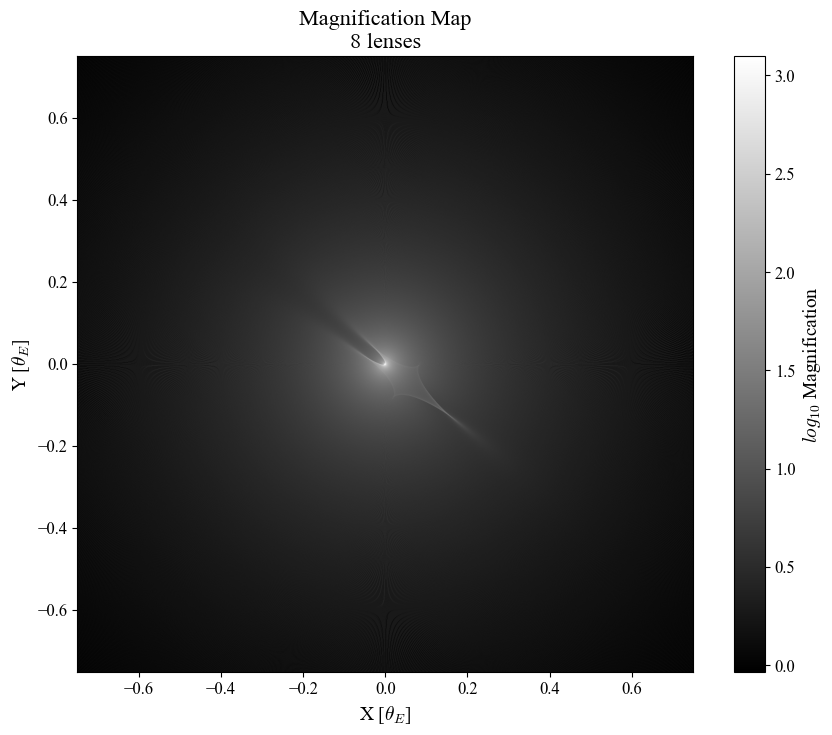

[[-6.76499369e-04  0.00000000e+00  1.00000000e+00]
 [ 8.06891367e-01 -6.43268690e-01  1.35552381e-03]
 [ 1.64114895e+00 -1.25229832e+00  5.15480886e-04]
 [ 2.68497948e+00  2.70548260e+00  6.19942768e-05]
 [ 1.58404249e+00  5.75620388e+00  7.31343348e-05]
 [-5.11459866e-02  1.92027201e-01  4.26495549e-06]
 [-3.79917664e-02 -1.38615988e-01  3.47593262e-06]
 [-3.02564858e-01 -2.05697679e-02  4.58256137e-07]
 [-7.36341793e-02 -2.41104289e-02  2.35739204e-07]]
4                b
5                c
6     False Uranus
7    False Neptune
2      False Earth
1      False Venus
3       False Mars
0    False Mercury
Name: Planet, dtype: object
Pixels = 4514, Angular Width = 1.5, Max Source Radius = 6.642182487729043, Min Source Radius = 0.06642182487729043
q = 0.0013555238122364413, s = 1.0324536148782077
q = 0.0005154808863434355, s = 2.0649072297564155
q = 6.199427676673783e-05, s = 3.8121364241656894
q = 7.313433477357085e-05, s = 5.970361576805329
q = 4.264955493302131e-06, s = 0.1985487720919

100%|██████████| 500/500 [00:03<00:00, 150.71it/s]


---------------------
Total time: 3.321 seconds
Plotting magnification map: 0.016 seconds


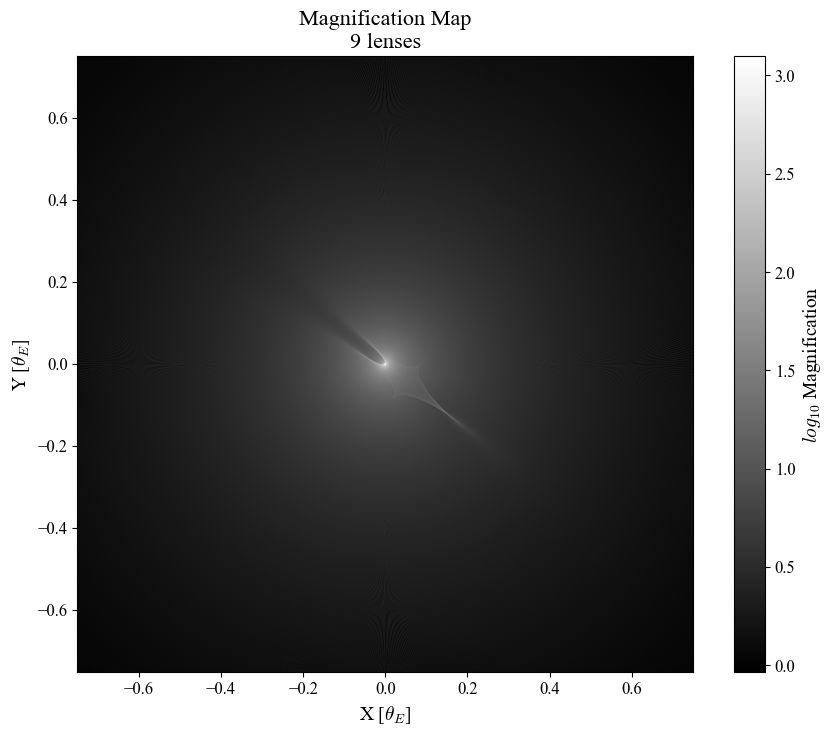

In [8]:
center_of_magnification = np.array([planet_attributes['q'].iloc[0] / ((1 + planet_attributes['q'].iloc[0]) * (planet_attributes['s'].iloc[0] + 1/planet_attributes['s'].iloc[0])), 0])
print(f'Binary offset: {center_of_magnification}')

lens_att[:, :2] -= center_of_magnification

# Iterating over all planets and consecutively creating magnification maps
for i in range(len(planets)):
    current_lens_att = lens_att[0:i+2, :]
    print(current_lens_att)
    current_planets = planet_attributes['Planet'].iloc[0:i+1]
    print(current_planets)

    pixels, ang_width, (qs, ss), cusp_points, (max_source_radius, min_source_radius) = IRSF.IRSFunctions._ang_width_calculator(current_lens_att, final_multiplier=1, pixels_in_small_source=20, cm_offset='auto')
    ang_width = 1.5
    print(f'Pixels = {pixels}, Angular Width = {ang_width}, Max Source Radius = {max_source_radius}, Min Source Radius = {min_source_radius}')

    (y_plus, y_minus), min_mag = IRSF.IRSFunctions._annulus_bounds_calculator(ang_width, qs, ss)
    print(f'Annulus bounds: y+ = {y_plus}, y- = {y_minus}, Min Magnification in Annulus = {min_mag}')

    num_r, num_theta = IRSF.IRSFunctions._num_ray_calculator(pixels, ang_width, y_plus, y_minus, min_mag, delta=0.01, r_theta_ratio=4)
    print(f'Number of rays: num_r = {num_r}, num_theta = {num_theta}, Total number of rays: {(num_r * num_theta):.3e}')

    lens_parameters = {
        'pixels': 1000,
        'ang_width': ang_width,
        'thickness': y_plus - y_minus,
        'y_plus': y_plus,
        'y_minus': y_minus,
        'lens_att': current_lens_att.tolist(),
        'num_theta': 5000,
        'num_r': 20000
    }
    
    sim_current_lens = IRSC.IRSCaustics(annulus_param_dict=lens_parameters)
    magnifications_current_lens = sim_current_lens.series_calculate(cm_offset='auto', annulus_offset=center_of_magnification)
    sim_current_lens.plot()

    plt.show()

Converting max and min source radii from Einstein radii to Solar radii

In [9]:
max_source_radius_solar = max_source_radius * theta_ein.to(u.rad).value * D_l.to(u.R_sun)
min_source_radius_solar = min_source_radius * theta_ein.to(u.rad).value * D_l.to(u.R_sun)

print(f'Max source radius: {max_source_radius_solar}')
print(f'Min source radius: {min_source_radius_solar}')

Max source radius: 3181.789898989943 solRad
Min source radius: 31.817898989899433 solRad


## Plotting simulations

Initializing some useful functions

In [11]:
def log_array(min_pow, max_pow):
    powers = np.arange(min_pow, max_pow + 1)
    base_values = np.array([1, 3])
    
    # Use broadcasting to create the sequence
    pos_arr = np.concatenate([base_values * (10.0**p) for p in powers])

    neg_arr = -pos_arr[::-1]

    return np.concatenate([neg_arr, np.array([0]), pos_arr])

def colors_by_log(arr):
    colors = []
    for val in arr:
        if val < 0:
            colors.append('blue')
        elif val == 0:
            colors.append('green')
        elif val > 0:
            colors.append('red')
    return colors

def half_decade_levels(data, num_steps=6, min_steps=3, keep_zero=True):
    '''Build symmetric half-decade contour levels adapted to the data range.

    Levels follow the base ``[1, 3]`` pattern (..., 1e-2, 3e-2, 1e-1, 3e-1,
    1, 3, ...) so each decade contributes two steps. The largest level is
    anchored to the biggest such step at or below the data's maximum absolute
    value, guaranteeing the outer contours are actually reached. ``num_steps``
    levels (>= ``min_steps``) are then placed per sign, with a 0 contour.
    '''
    num_steps = max(num_steps, min_steps)

    base = (1.0, 3.0)

    def value_at(k):
        # Maps integer index k -> base[1, 3] level, e.g. k=0 -> 1, k=1 -> 3,
        # k=2 -> 10, k=-1 -> 0.3, k=-2 -> 0.1 (floor division handles k<0).
        return base[k % 2] * 10.0 ** (k // 2)

    finite = data[np.isfinite(data)]
    max_abs = np.max(np.abs(finite)) if finite.size else 0.0

    if not np.isfinite(max_abs) or max_abs <= 0:
        # Flat / degenerate map: fall back to a sane default range (top -> 0.3).
        top = -1
    else:
        # Largest [1, 3] step at/below the data max (overshoot, then back off).
        top = int(np.ceil(2 * np.log10(max_abs)))
        while value_at(top) > max_abs:
            top -= 1

    # Descending indices top, top-1, ... -> ascending positive levels.
    pos = np.sort([value_at(top - j) for j in range(num_steps)])
    neg = -pos[::-1]

    if keep_zero:
        return np.concatenate([neg, [0.0], pos])
    else:
        return np.concatenate([neg, pos])

def linewidths_by_level(levels, min_lw=0.3, max_lw=1.3):
    '''Thicker lines for larger-magnitude contours, symmetric about 0.'''
    pos_levels = sorted({abs(v) for v in levels if v != 0})
    n = len(pos_levels)
    if n > 1:
        lw_map = {lv: min_lw + (max_lw - min_lw) * idx / (n - 1)
                    for idx, lv in enumerate(pos_levels)}
    elif n == 1:
        lw_map = {pos_levels[0]: max_lw}
    else:
        lw_map = {}

    lws = []
    for v in levels:
        if v == 0:
            lws.append((min_lw + max_lw) / 2)
        else:
            lws.append(lw_map[abs(v)])
    return lws

Importing simulations data

In [12]:
sims = []

for i in range(len(planets)):
    print(f'Processing {i+1} planets...')
    current_planets = planet_attributes['Planet'].iloc[0:i+1]
    print(current_planets)

    file_name = current_planets.iloc[0]
    for i, planet in enumerate(current_planets.values):
        if i != 0:
            file_name += f'_{planet}'
    file_name += '.pkl'

    file_path = f'../../Unity/Simulations/Part_6_OGLE_System_Collection/{file_name}'

    print(f'Simulation file path: {file_path}')

    sim_current_lens = IRSC.caustic_reader(file_path)
    # sim_current_lens.plot()
    # plt.savefig(f'./Unity Analysis/Part 6/Figures/OGLE System/ogle_system_magnification_map_{file_name}.png', dpi=300)

    sims.append(sim_current_lens)

Processing 1 planets...
4    b
Name: Planet, dtype: object
Simulation file path: ../../Unity/Simulations/Part_6_OGLE_System_Collection/b.pkl
Processing 2 planets...
4    b
5    c
Name: Planet, dtype: object
Simulation file path: ../../Unity/Simulations/Part_6_OGLE_System_Collection/b_c.pkl
Processing 3 planets...
4               b
5               c
6    False Uranus
Name: Planet, dtype: object
Simulation file path: ../../Unity/Simulations/Part_6_OGLE_System_Collection/b_c_False Uranus.pkl
Processing 4 planets...
4                b
5                c
6     False Uranus
7    False Neptune
Name: Planet, dtype: object
Simulation file path: ../../Unity/Simulations/Part_6_OGLE_System_Collection/b_c_False Uranus_False Neptune.pkl
Processing 5 planets...
4                b
5                c
6     False Uranus
7    False Neptune
2      False Earth
Name: Planet, dtype: object
Simulation file path: ../../Unity/Simulations/Part_6_OGLE_System_Collection/b_c_False Uranus_False Neptune_False Earth.p

In [15]:
print('Angular resolution: ', sims[0].ang_res)
print('Angular width: ', sims[0].ang_width)
print('Pixels: ', sims[0].pixels)
print('Number of rays: ', sims[0].num_r * sims[0].num_theta)

Angular resolution:  0.0003322995126273815
Angular width:  1.5
Pixels:  4514
Number of rays:  571436212356


Defining source profile

Defining source profile...
Source radius: 0.09610965672655125 mas
Source radius: 0.06471441033393359 theta_E


100%|██████████| 389/389 [00:00<00:00, 2901.69it/s]


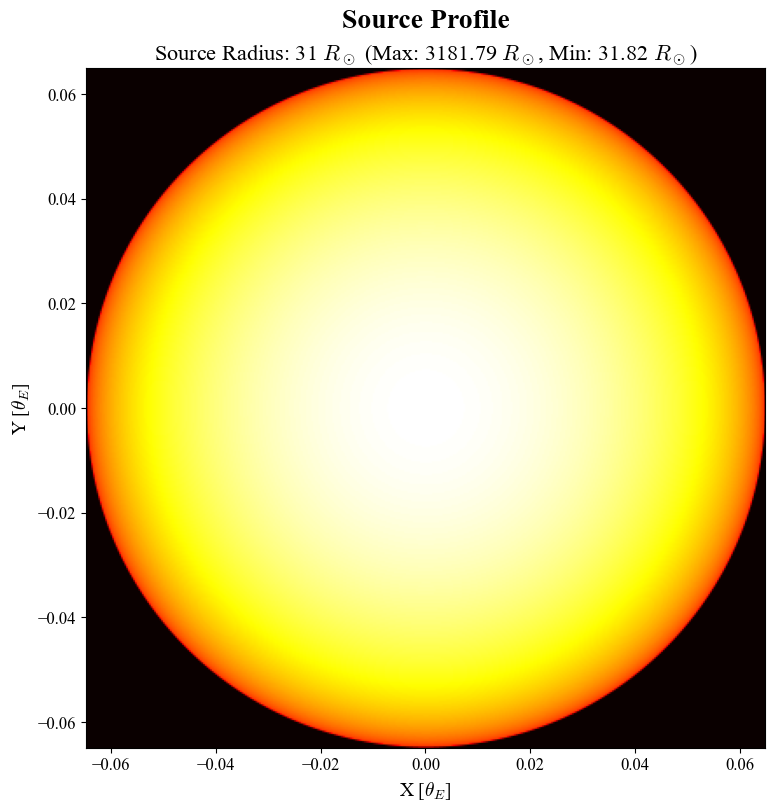

In [13]:
radius = 31
ang_res = sims[0].ang_res

print('Defining source profile...')
source_radius_solar = radius * c.R_sun.to(u.m).value # meters
source_radius_angular = source_radius_solar / D_l.to(u.m).value * u.rad # radians
print(f'Source radius: {source_radius_angular.to(u.mas)}')
source_radius = source_radius_angular.to(u.mas).value / theta_ein.to(u.mas).value # theta_E
print(f'Source radius: {source_radius} theta_E')

source_profile = IRSF.IRSFunctions.source_profile(ang_res=ang_res, profile_type='LD', rad=source_radius, LD=0.5)

fig = plt.figure()
fig.set_constrained_layout(True)
ax = fig.add_subplot()

fig.suptitle('Source Profile')

ax.set_title(f'Source Radius: {radius} $R_\odot$ (Max: {max_source_radius_solar.to(u.R_sun).value:.2f} $R_\odot$, Min: {min_source_radius_solar.to(u.R_sun).value:.2f} $R_\odot$)')

ax.imshow(source_profile, cmap='hot', extent=(-source_radius - ang_res/2, source_radius + ang_res/2, -source_radius - ang_res/2, source_radius + ang_res/2))

ax.set_xlabel(r'X [$\theta_E$]')
ax.set_ylabel(r'Y [$\theta_E$]')

ax.set_aspect('equal')

plt.show()

Convolving magnification maps with source profile

In [14]:
convolved_brightnesses = []
for sim in sims:
    convolved_brightnesses.append(sim.convolve(source_profile=source_profile))

Convolving source profile with magnification map: 2.221 seconds
Convolving source profile with magnification map: 1.917 seconds
Convolving source profile with magnification map: 2.062 seconds
Convolving source profile with magnification map: 1.905 seconds
Convolving source profile with magnification map: 1.897 seconds
Convolving source profile with magnification map: 1.834 seconds
Convolving source profile with magnification map: 1.98 seconds
Convolving source profile with magnification map: 1.984 seconds


Plotting fractional difference maps

Processing 2 - 1 planets...
Contour levels: [-0.003  -0.001  -0.0003  0.0003  0.001   0.003 ]


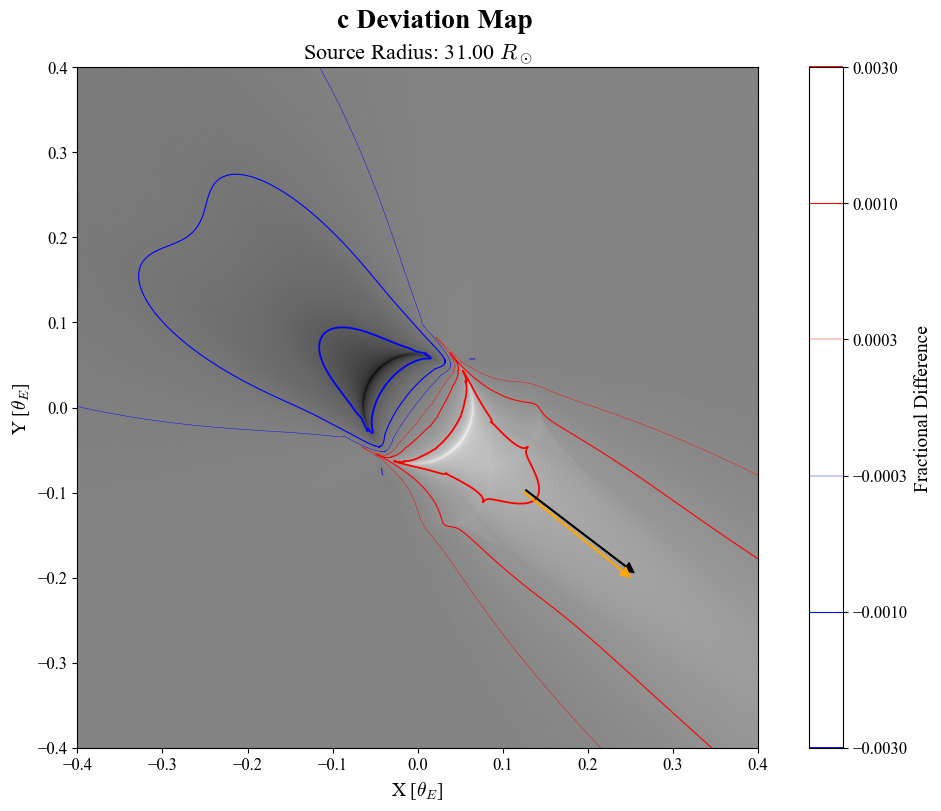

Processing 3 - 2 planets...
Contour levels: [-3.e-04 -1.e-04 -3.e-05  3.e-05  1.e-04  3.e-04]


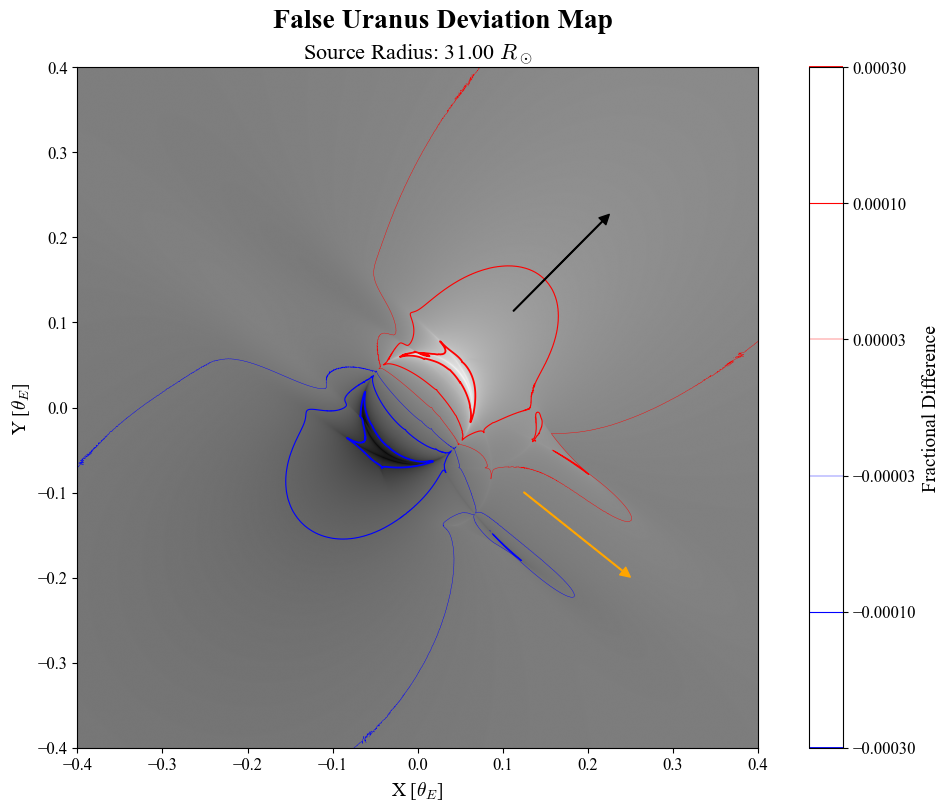

Processing 4 - 3 planets...
Contour levels: [-3.e-04 -1.e-04 -3.e-05  3.e-05  1.e-04  3.e-04]


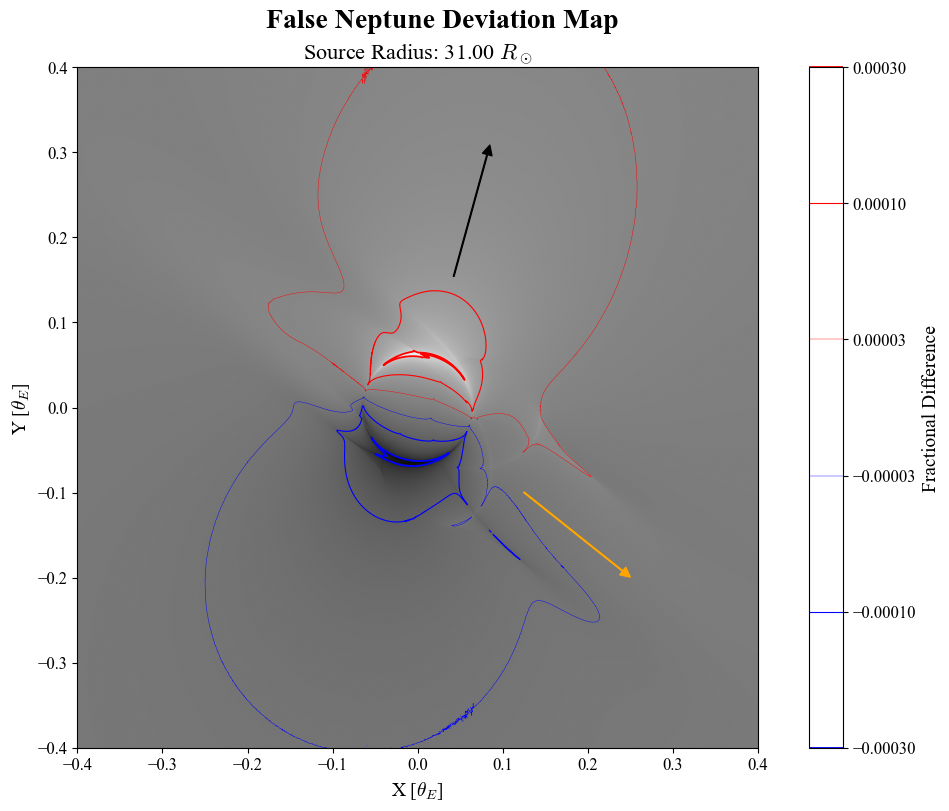

Processing 5 - 4 planets...
Contour levels: [-3.e-05 -1.e-05 -3.e-06  3.e-06  1.e-05  3.e-05]


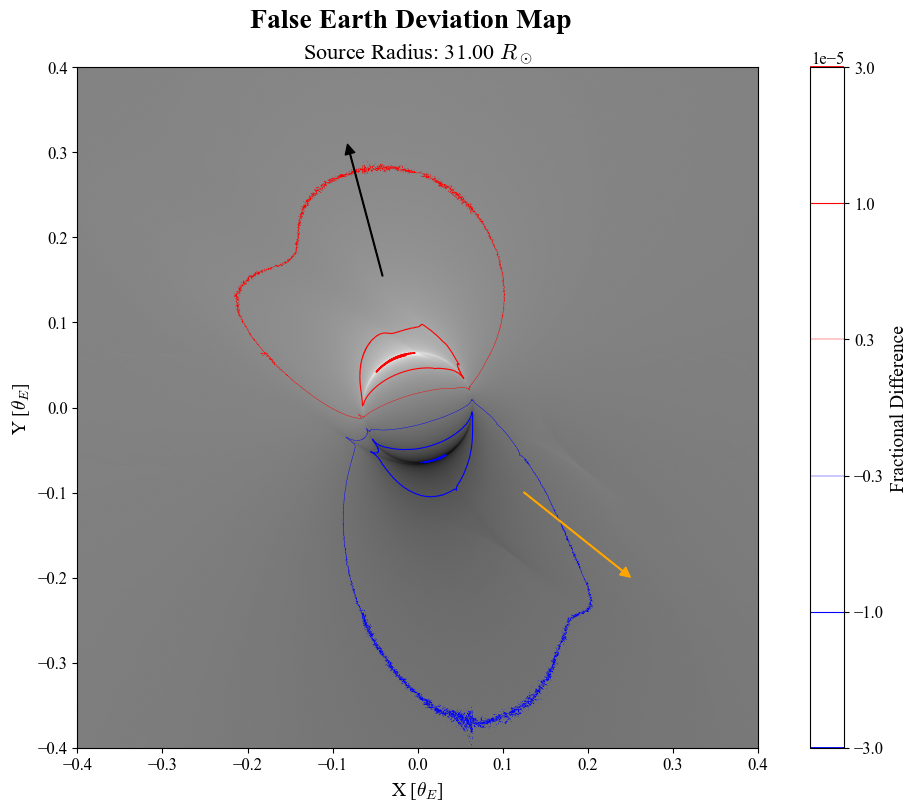

Processing 6 - 5 planets...
Contour levels: [-1.e-05 -3.e-06 -1.e-06  1.e-06  3.e-06  1.e-05]


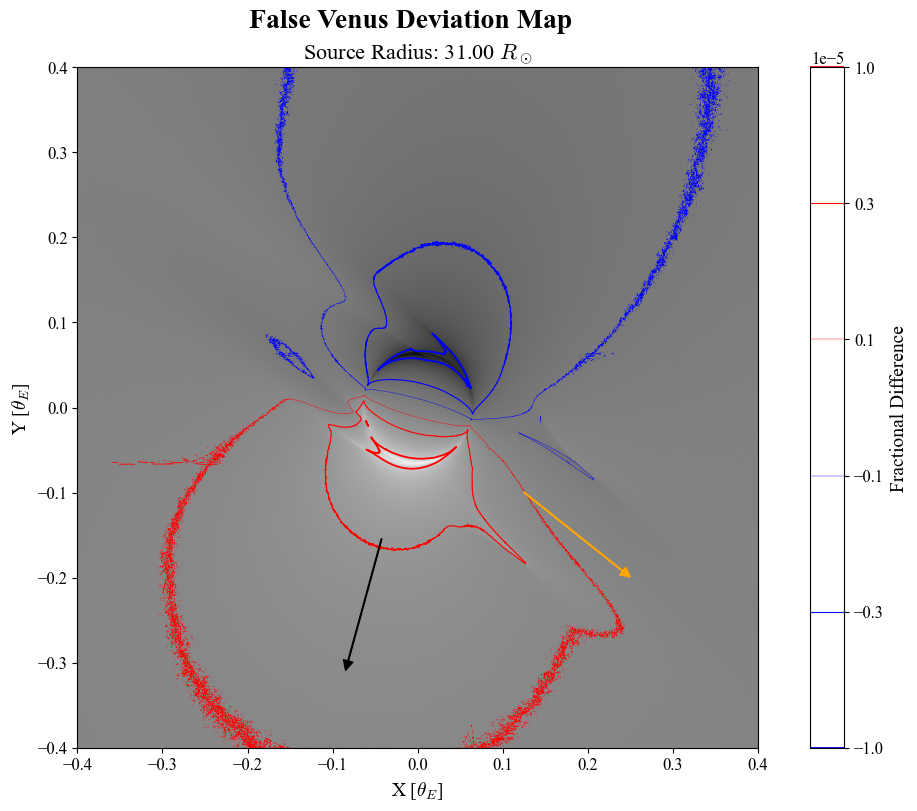

Processing 7 - 6 planets...
Contour levels: [-3.e-06 -1.e-06 -3.e-07  3.e-07  1.e-06  3.e-06]


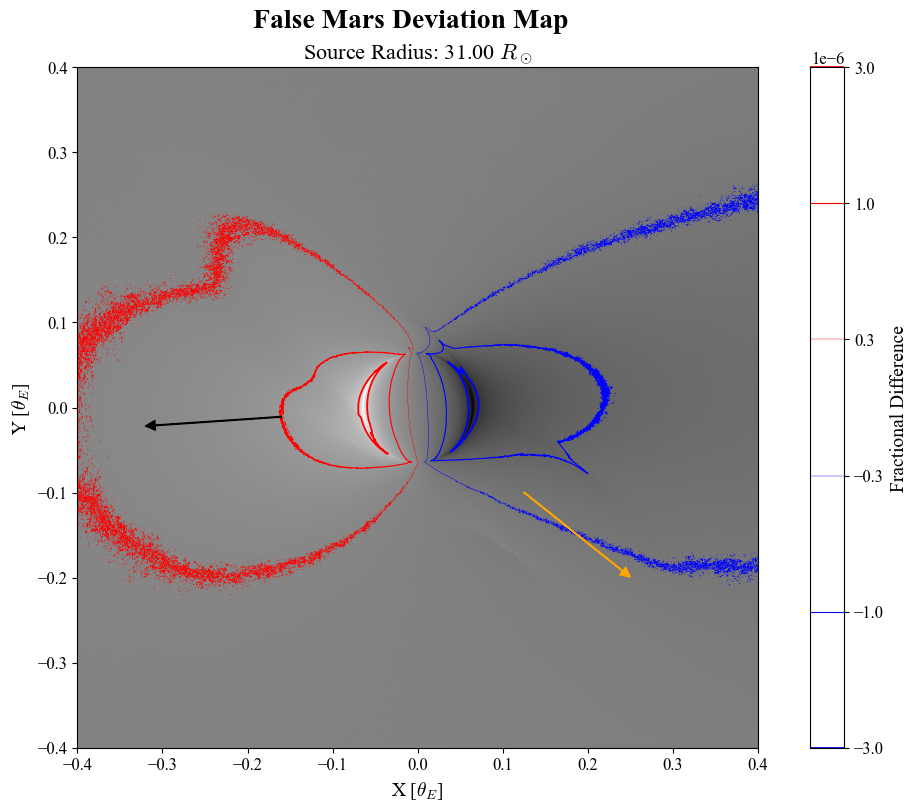

Processing 8 - 7 planets...
Contour levels: [-3.e-07 -1.e-07 -3.e-08  3.e-08  1.e-07  3.e-07]


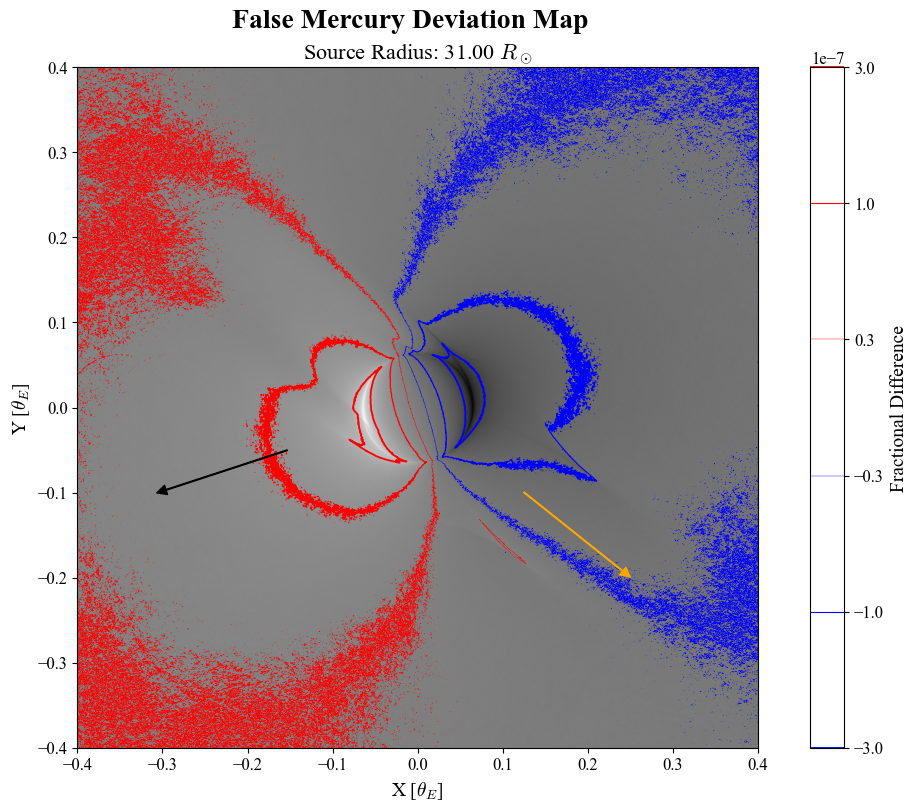

In [12]:
save = False
view = 0.4

frac_diff_maps = []

for i in range(len(sims)-1):
    print(f'Processing {i+2} - {i+1} planets...')

    current_sim = sims[i]
    next_sim = sims[i+1]

    ang_width = current_sim.ang_width
    ang_res = current_sim.ang_res

    frac_diff_map = (convolved_brightnesses[i+1] - convolved_brightnesses[i]) / convolved_brightnesses[i]
    frac_diff_maps.append(frac_diff_map)

    fig = plt.figure()
    fig.set_constrained_layout(True)
    ax = fig.add_subplot()

    fig.suptitle(f'{planet_attributes["Planet"].iloc[i+1]} Deviation Map')
    ax.set_title(f'Source Radius: {radius:.2f} $R_\odot$')

    plot = ax.imshow(frac_diff_map, 
                    cmap='gray',
                    extent=[-ang_width/2 - ang_res/2, ang_width/2 + ang_res/2, -ang_width/2 - ang_res/2, ang_width/2 + ang_res/2],
    )
    # Adapt contour levels to this map so lines are always visible, even
    # when subtracting small planets shrinks the fractional deviations.
    levels = half_decade_levels(frac_diff_map, num_steps=3, min_steps=3, keep_zero=False)
    print(f'Contour levels: {levels}')

    plot = ax.contour(np.flip(frac_diff_map, axis=0),
            levels=levels,
            colors=colors_by_log(levels),
            linewidths=linewidths_by_level(levels),
            extent=[-ang_width/2 - ang_res/2, ang_width/2 + ang_res/2, -ang_width/2 - ang_res/2, ang_width/2 + ang_res/2]
    )

    bar = plt.colorbar(plot)
    bar.set_label('Fractional Difference')

    # Creating an arrow pointing in the direction of the planet
    x_arrow = lens_att[i+2, 0] / planet_attributes['s'].iloc[i+1] * view
    y_arrow = lens_att[i+2, 1] / planet_attributes['s'].iloc[i+1] * view
    x_origin = x_arrow / 2
    y_origin = y_arrow / 2
    ax.annotate('', xy=(x_arrow + 0.5, y_arrow + 0.5), xytext=(x_origin + 0.5, y_origin + 0.5), arrowprops=dict(color='black', width=0.5, headwidth=7, headlength=7), xycoords='axes fraction')

    # Creating an arrow pointing in the direction of Jupiter
    x_arrow = lens_att[1, 0] / planet_attributes['s'].iloc[0] * view
    y_arrow = lens_att[1, 1] / planet_attributes['s'].iloc[0] * view
    x_origin = x_arrow / 2
    y_origin = y_arrow / 2
    ax.annotate('', xy=(x_arrow + 0.5, y_arrow + 0.5), xytext=(x_origin + 0.5, y_origin + 0.5), arrowprops=dict(color='orange', width=0.5, headwidth=7, headlength=7), xycoords='axes fraction')

    ax.set_xlabel(r'X [$\theta_E$]')
    ax.set_ylabel(r'Y [$\theta_E$]')

    ax.set_xlim(-view, view)
    ax.set_ylim(-view, view)

    ax.set_aspect('equal')

    if save:
        plt.savefig(f'../../Unity Analysis/Part 6/Figures/Solar System/frac_diff_solar_sys_{i+2}_{i+1}_{radius:.2e}.png', dpi=300)
        print(f'Fractional difference map saved successfully for {i+2} - {i+1} planets.')

    plt.show()

## Calculating light curves

In [13]:
def t_E_calculator(M : astropy.units.Quantity, pi_rel : astropy.units.Quantity, mu_rel : astropy.units.Quantity) -> astropy.units.Quantity:
    '''
    Calculates the Einstein crossing time for a microlensing event (Equation 10 from Gaudi 2010).

    Parameters
    ----------
    M : astropy.units.Quantity
        Mass of the lens
    pi_rel : astropy.units.Quantity
        Relative parallax
    mu_rel : astropy.units.Quantity
        Relative proper motion

    Returns
    -------
    t_E : astropy.units.Quantity
        Einstein crossing time
    '''
    return (19*u.day * (M / (0.3*c.M_sun))**0.5 * (pi_rel / (125*u.uas))**0.5 * (mu_rel / (10.5*u.mas/u.yr))**-1).to(u.day)

# Relative distance
D_rel = (D_l**-1 - D_s**-1)**-1
print(f'Distance to lens: {D_l}')
print(f'Distance to source: {D_s}')
print(f'Relative distance: {D_rel}')

# Defining relative parallax
pi_rel = (u.AU / D_rel).to(u.dimensionless_unscaled).value * u.rad
print(f'Relative parallax: {pi_rel.to(u.mas)}')

# Definnig relative proper motion
mu_rel = 10 * u.mas / u.yr
print(f'Relative proper motion: {mu_rel}')

# Calculating Einstein time
t_E = t_E_calculator(M_star, pi_rel, mu_rel)
print(f'Einstein time: {t_E:.2f}')

# Einstein ring radius
print(f'Einstein ring radius: {r_ein:.2f}')

# Einsteing ring radius in mas
print(f'Einstein ring angle: {theta_ein:.2f}')

Distance to lens: 1.5 kpc
Distance to source: 8.0 kpc
Relative distance: 1.8461538461538463 kpc
Relative parallax: 0.5416666666666665 mas
Relative proper motion: 10.0 mas / yr
Einstein time: 53.61 d
Einstein ring radius: 2.23 AU
Einstein ring angle: 1.49 mas


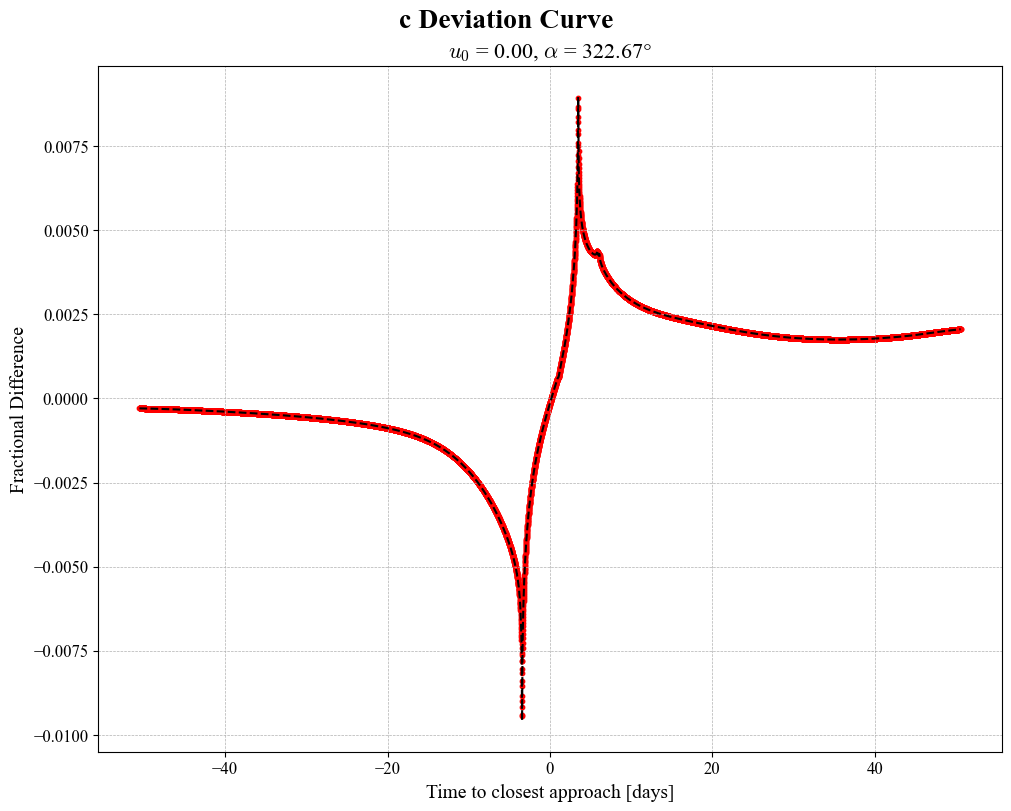

Contour levels: [-0.003  -0.001  -0.0003  0.0003  0.001   0.003 ]


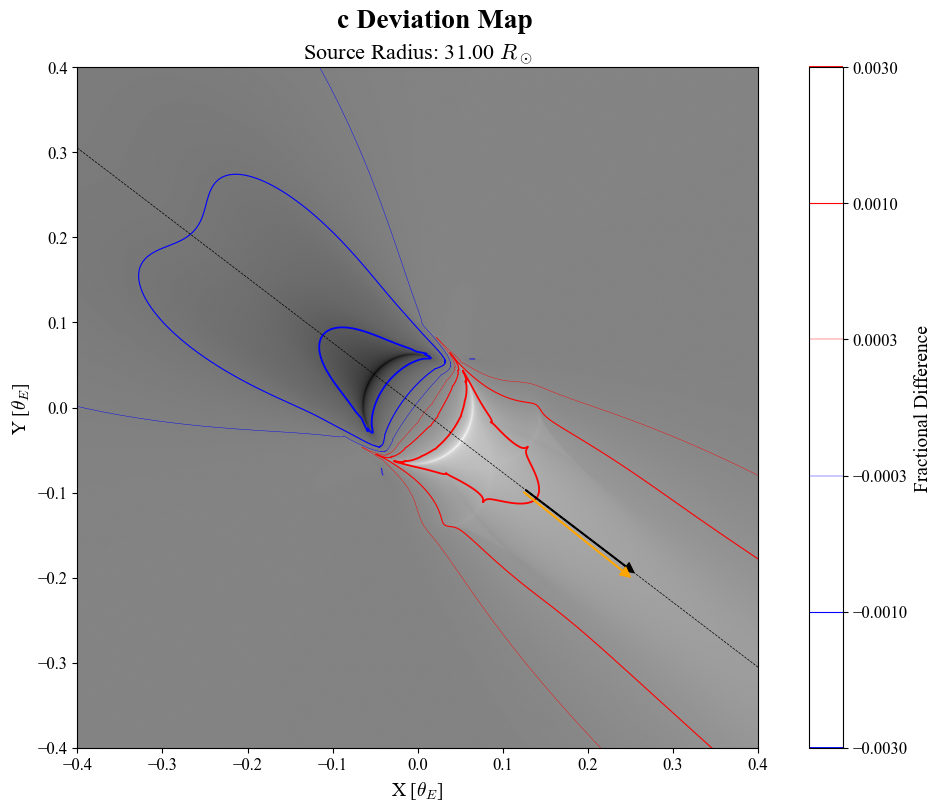

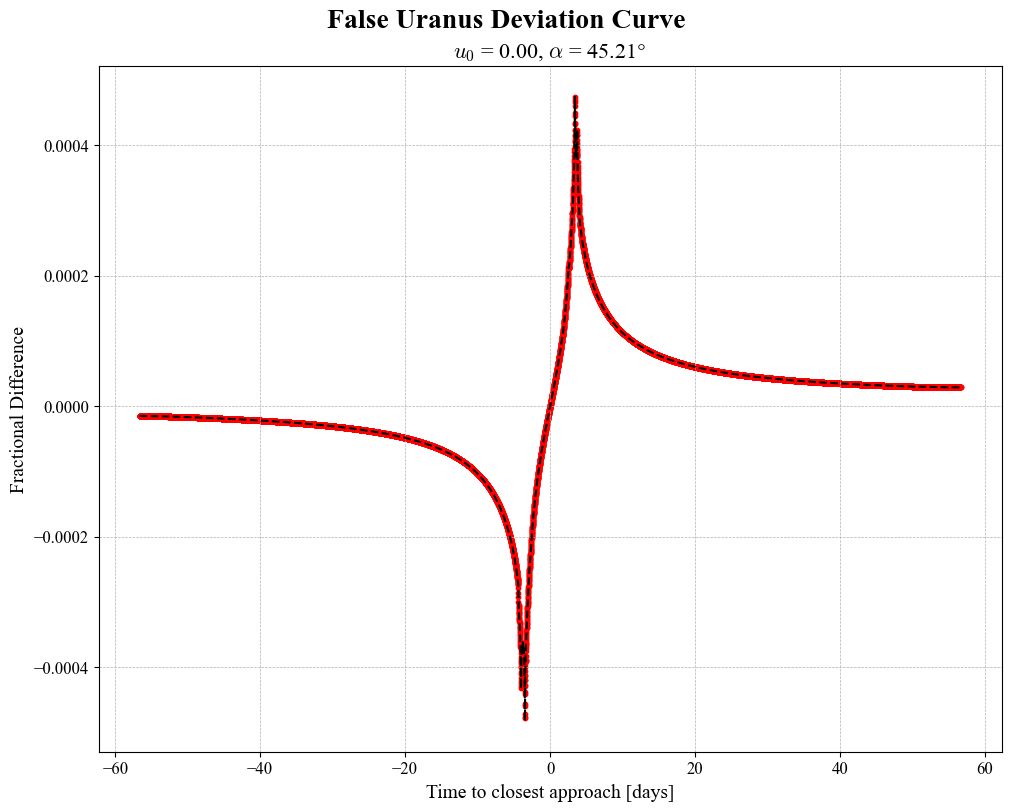

Contour levels: [-3.e-04 -1.e-04 -3.e-05  3.e-05  1.e-04  3.e-04]


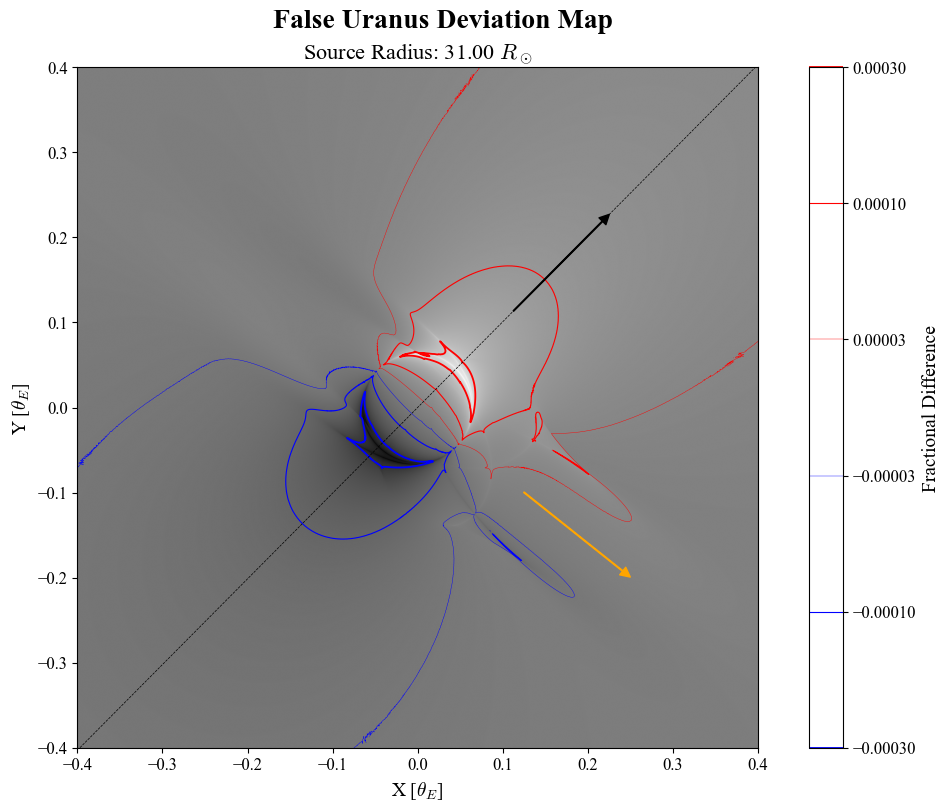

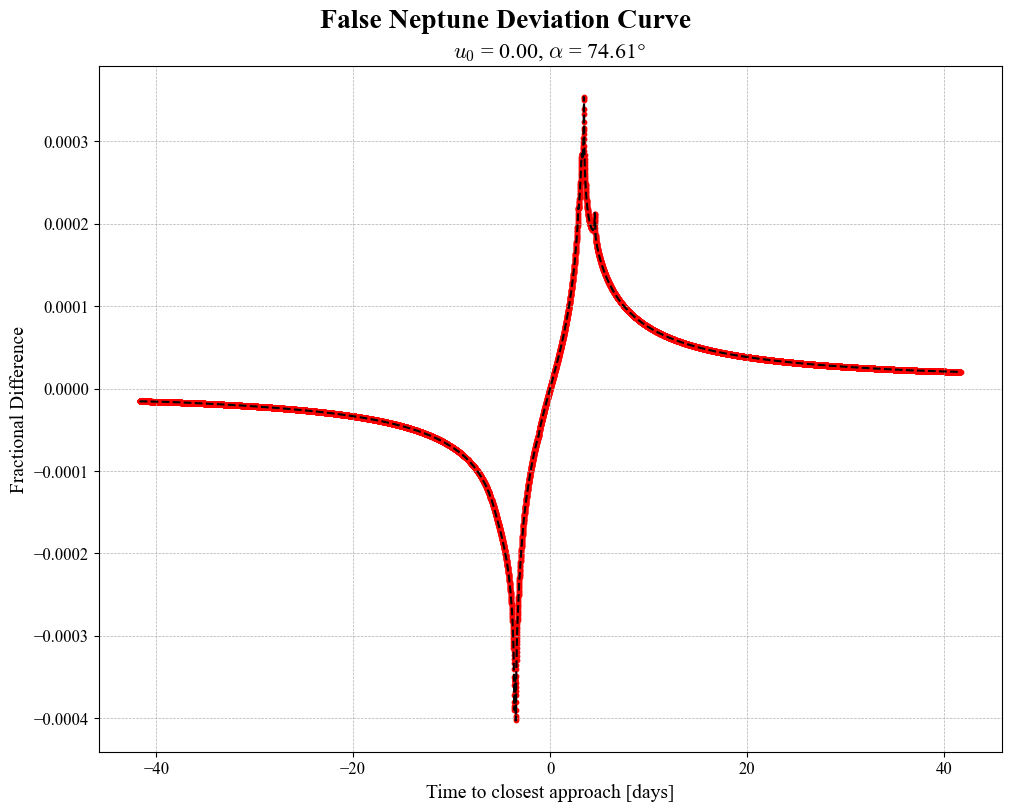

Contour levels: [-3.e-04 -1.e-04 -3.e-05  3.e-05  1.e-04  3.e-04]


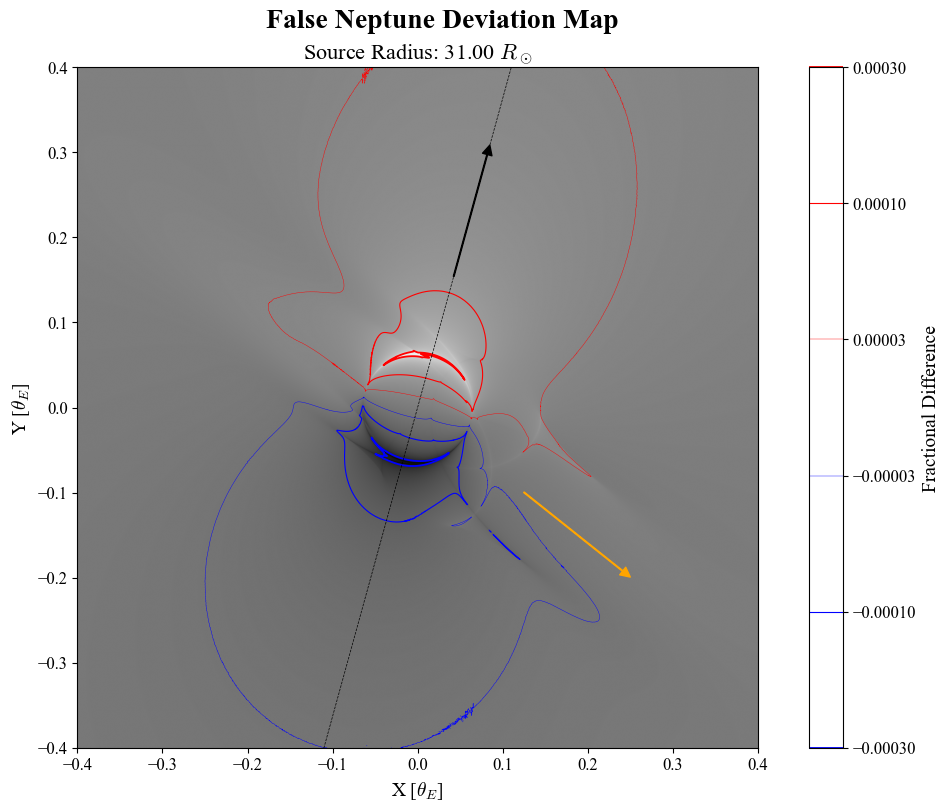

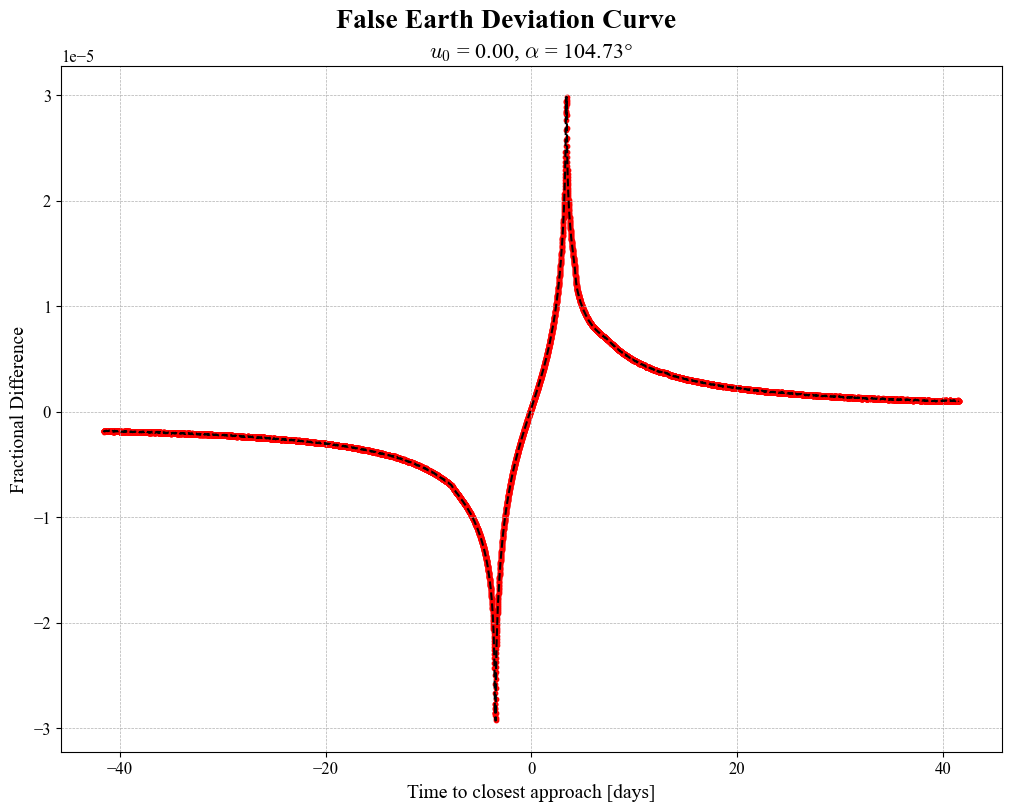

Contour levels: [-3.e-05 -1.e-05 -3.e-06  3.e-06  1.e-05  3.e-05]


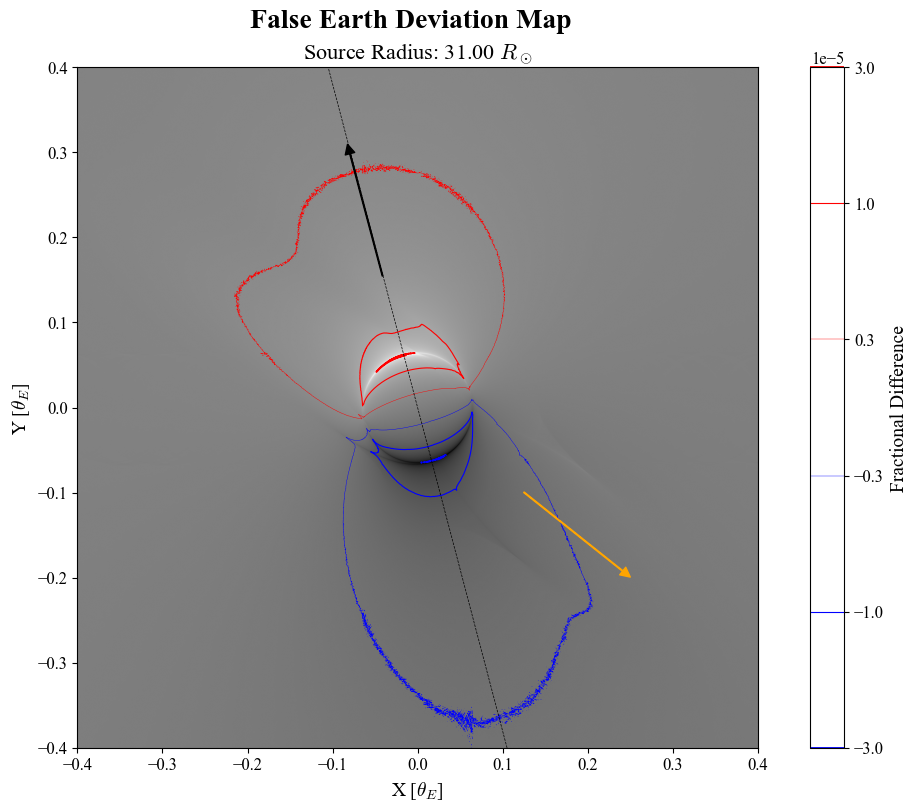

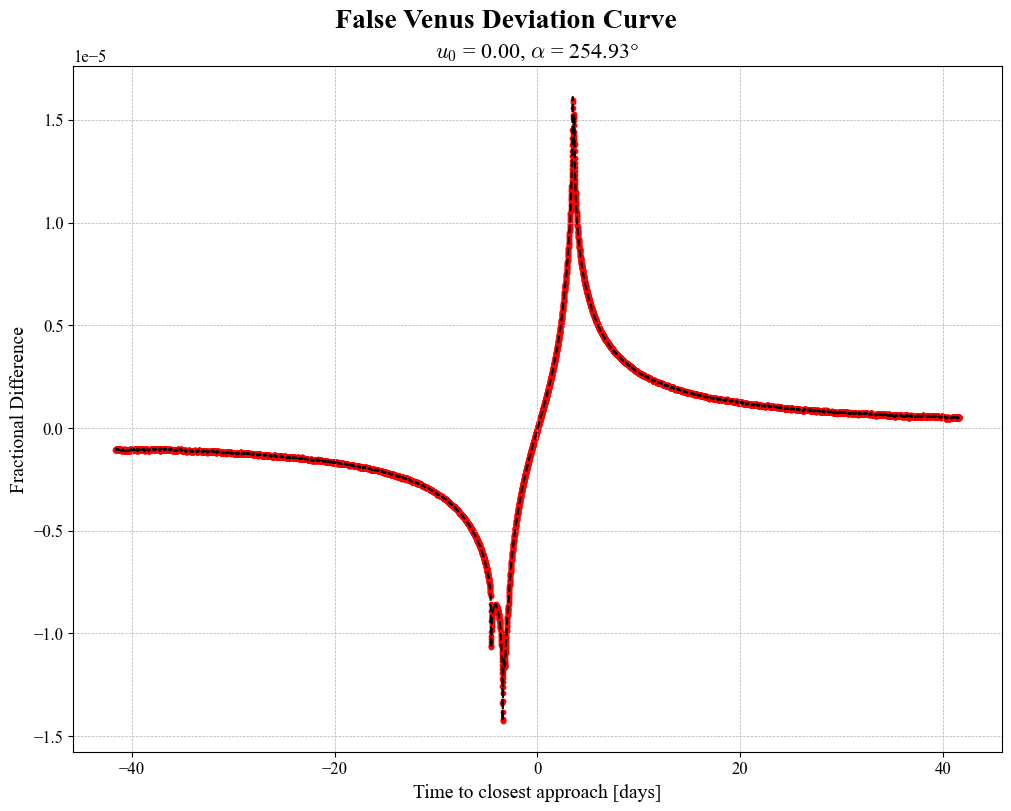

Contour levels: [-1.e-05 -3.e-06 -1.e-06  1.e-06  3.e-06  1.e-05]


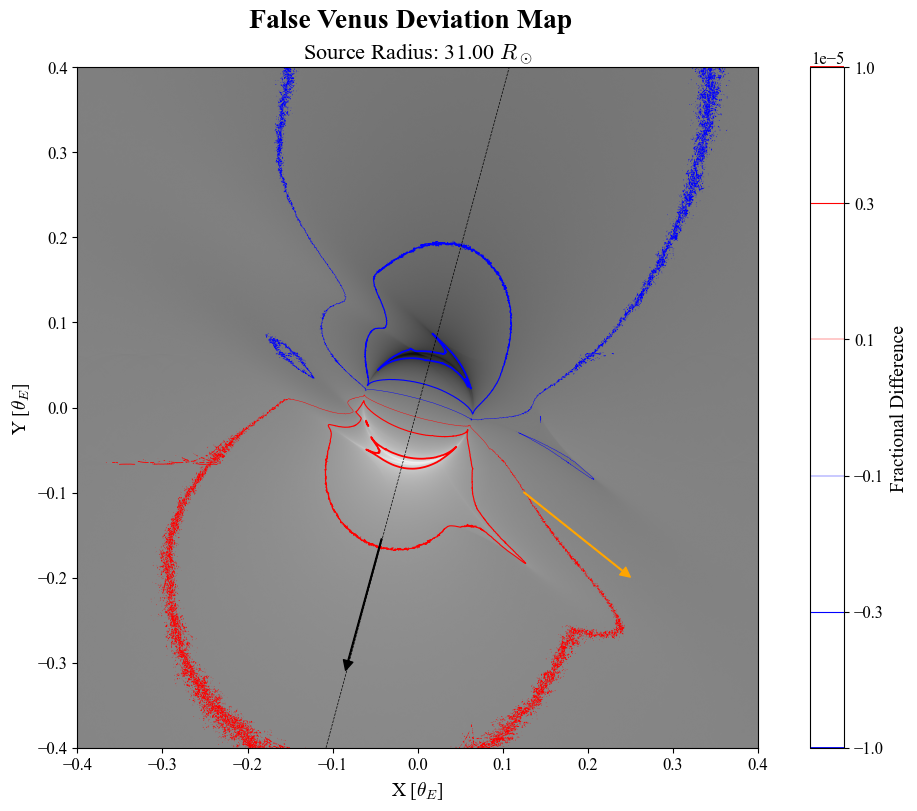

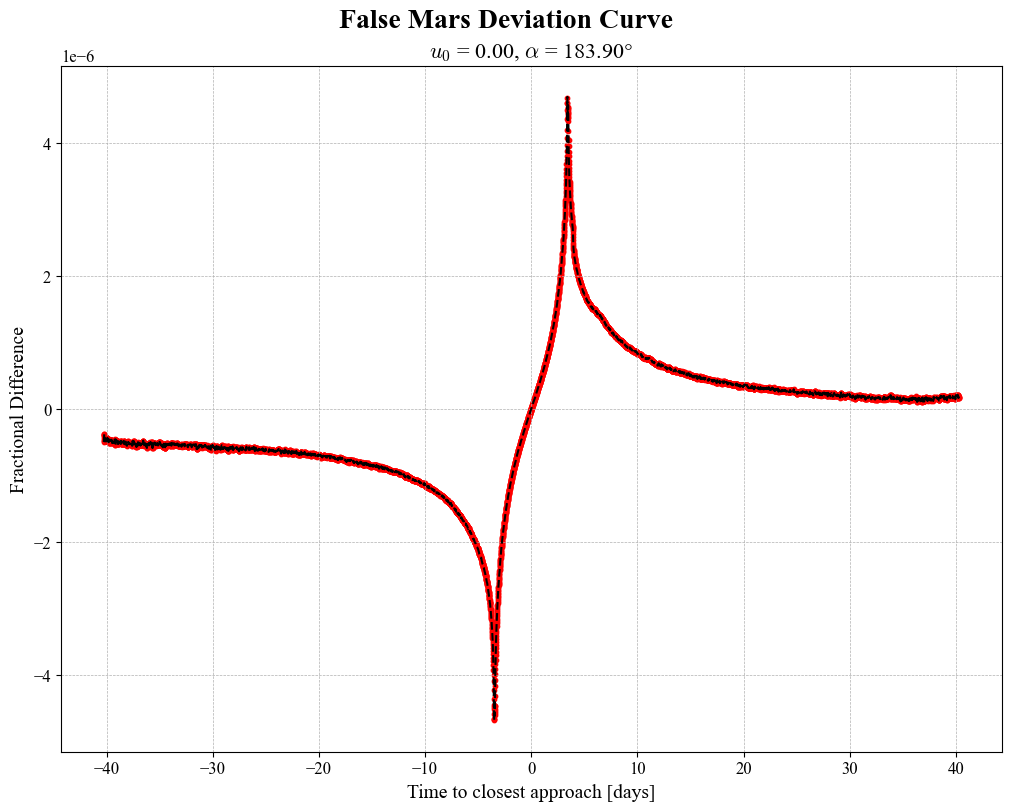

Contour levels: [-3.e-06 -1.e-06 -3.e-07  3.e-07  1.e-06  3.e-06]


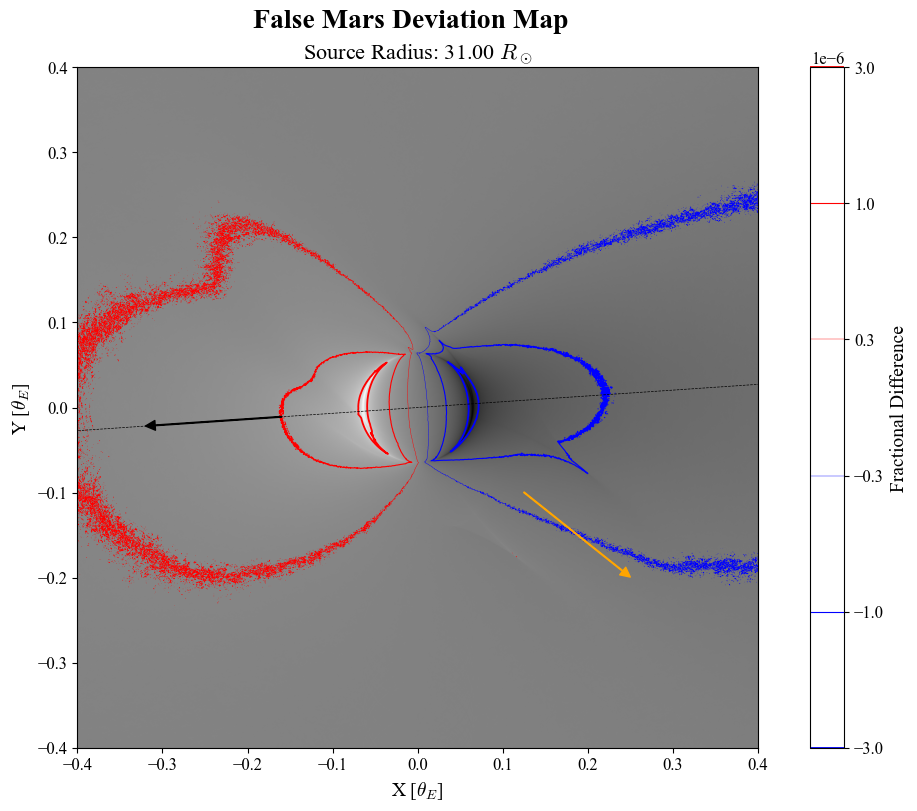

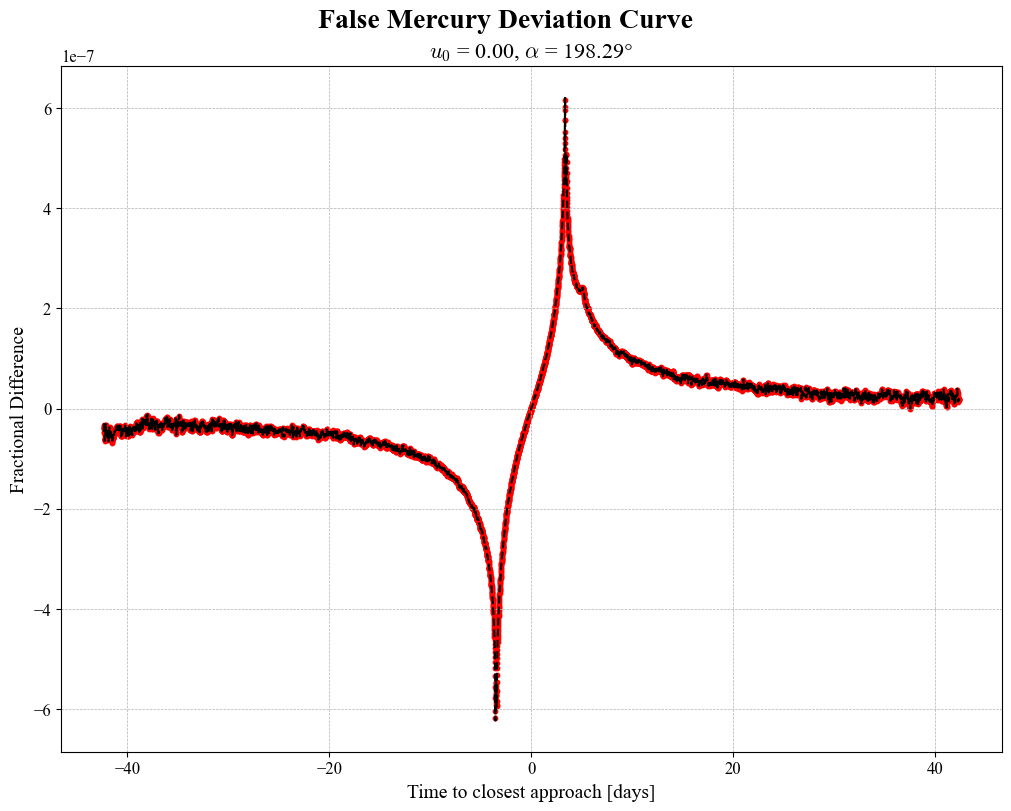

Contour levels: [-3.e-07 -1.e-07 -3.e-08  3.e-08  1.e-07  3.e-07]


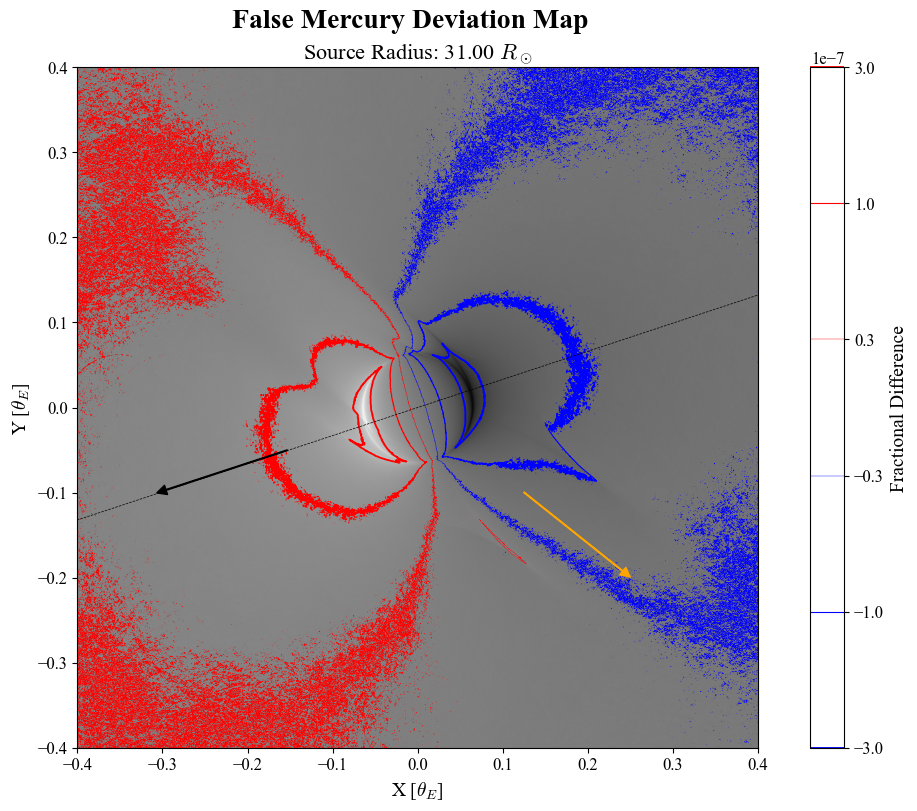

In [15]:
for i in range(len(sims)-1):
    u_0 = 0
    alpha = planet_attributes['Angle [deg]'].iloc[i+1]

    times, line_values, (xs, ys) = IRSF.IRSFunctions.lightcurve_calculator(frac_diff_maps[i], ang_width, u_0, alpha, t_0=0, t_E=t_E.value)

    fig = plt.figure()
    fig.set_constrained_layout(True)
    ax = fig.add_subplot()

    fig.suptitle(f'{planet_attributes["Planet"].iloc[i+1]} Deviation Curve')

    ax.set_title(f'$u_0$ = {u_0:.2f}, $\\alpha$ = {alpha:.2f}$\\degree$')

    ax.plot(times, line_values, color='black', linestyle='--')

    # Plotting a 12-minute cadence light curve
    times_12min = np.arange(times[0], times[-1], 12/60/24)
    line_values_12min = np.interp(times_12min, times, line_values)
    ax.scatter(times_12min, line_values_12min, c='red', s=10)

    ax.set_xlabel(r'Time to closest approach [days]')
    ax.set_ylabel(r'Fractional Difference')

    ax.grid(True, which='both', linestyle='--', linewidth=0.5)

    plt.show()

    fig = plt.figure()
    fig.set_constrained_layout(True)
    ax = fig.add_subplot()

    fig.suptitle(f'{planet_attributes["Planet"].iloc[i+1]} Deviation Map')
    ax.set_title(f'Source Radius: {radius:.2f} $R_\odot$')

    plot = ax.imshow(frac_diff_maps[i], 
                    cmap='gray',
                    extent=[-ang_width/2 - ang_res/2, ang_width/2 + ang_res/2, -ang_width/2 - ang_res/2, ang_width/2 + ang_res/2],
    )
    # Adapt contour levels to this map so lines are always visible, even
    # when subtracting small planets shrinks the fractional deviations.
    levels = half_decade_levels(frac_diff_maps[i], num_steps=3, min_steps=3, keep_zero=False)
    print(f'Contour levels: {levels}')

    plot = ax.contour(np.flip(frac_diff_maps[i], axis=0),
            levels=levels,
            colors=colors_by_log(levels),
            linewidths=linewidths_by_level(levels),
            extent=[-ang_width/2 - ang_res/2, ang_width/2 + ang_res/2, -ang_width/2 - ang_res/2, ang_width/2 + ang_res/2]
    )

    bar = plt.colorbar(plot)
    bar.set_label('Fractional Difference')

    # Creating an arrow pointing in the direction of the planet
    x_arrow = lens_att[i+2, 0] / planet_attributes['s'].iloc[i+1] * view
    y_arrow = lens_att[i+2, 1] / planet_attributes['s'].iloc[i+1] * view
    x_origin = x_arrow / 2
    y_origin = y_arrow / 2
    ax.annotate('', xy=(x_arrow + 0.5, y_arrow + 0.5), xytext=(x_origin + 0.5, y_origin + 0.5), arrowprops=dict(color='black', width=0.5, headwidth=7, headlength=7), xycoords='axes fraction')

    # Creating an arrow pointing in the direction of Jupiter
    x_arrow = lens_att[1, 0] / planet_attributes['s'].iloc[0] * view
    y_arrow = lens_att[1, 1] / planet_attributes['s'].iloc[0] * view
    x_origin = x_arrow / 2
    y_origin = y_arrow / 2
    ax.annotate('', xy=(x_arrow + 0.5, y_arrow + 0.5), xytext=(x_origin + 0.5, y_origin + 0.5), arrowprops=dict(color='orange', width=0.5, headwidth=7, headlength=7), xycoords='axes fraction')

    ax.plot(xs, ys, 'k--', linewidth=0.5)

    ax.set_xlabel(r'X [$\theta_E$]')
    ax.set_ylabel(r'Y [$\theta_E$]')

    ax.set_xlim(-view, view)
    ax.set_ylim(-view, view)

    ax.set_aspect('equal')

    plt.show()